# 03 — Clustering: Countries, Products & Sectors
## Forecasting and Identifying Global Export Opportunities for Algerian Exporters
**ENSIA — Machine Learning Project — Spring 2025/2026**

---

## Notebook Purpose

This notebook implements **Step 3a — Clustering Tasks** from the project methodology.

Three distinct clustering analyses are carried out:

| Task | Unit of analysis | Business goal |
|------|-----------------|---------------|
| **Country clustering** | One row = one partner country | Group the 227 partner countries by their import demand profile so that Algeria can identify priority market segments |
| **Product clustering** | One row = one HS6 product | Group the HS6 products by global demand pattern to identify product categories with the strongest growth potential |
| **Sector clustering** | One row = one HS2 sector | Group the 97 HS2 sectors to understand structural differences in demand and Algeria's comparative position |

All three analyses work on compact aggregated tables derived from the modeling split saved in Notebook 02. The raw 14-million-row master dataset is never loaded in full — peak RAM stays well below 1 GB.

---

## What this notebook covers

1. Setup and data loading
2. Country clustering — feature construction, optimal-k search, K-Means, Agglomerative, evaluation, interpretation, priority market ranking
3. Product clustering — feature construction, optimal-k search, K-Means, Agglomerative, evaluation, interpretation
4. Sector clustering — feature construction, optimal-k search, K-Means, Agglomerative, evaluation, interpretation
5. Cross-analysis — opportunity rate by country cluster × product cluster
6. Full evaluation summary
7. Save all outputs for dashboard use

---

## Coverage of project requirements

- Group countries based on import demand patterns ✓
- Cluster products based on global demand trends ✓
- Cluster sectors based on demand structure and Algeria's position ✓
- Identify similar export markets and produce a priority market ranking ✓
- Evaluation: Silhouette Score, Davies-Bouldin Index ✓
- Two algorithms per task (K-Means + Agglomerative Ward) ✓
- Economic interpretability and strategic labelling ✓
- Outputs saved for dashboard integration ✓


---
## 0. Imports and Configuration

All libraries required for clustering (scikit-learn), numerical computation (NumPy, pandas), and visualisation (matplotlib, seaborn) are loaded here. Paths are configured relative to the project root so the notebook runs from either the `notebooks/` subdirectory or the root itself.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, zscore
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

ROOT         = Path("..") if Path.cwd().name == "notebooks" else Path(".")
DATA_DIR     = ROOT / "data"
MODELING_DIR = DATA_DIR / "modeling"
OUTPUT_DIR   = DATA_DIR / "clustering_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
PALETTE      = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#c0392b", "#16a085"]

for fname in ["train.parquet", "val.parquet", "test.parquet"]:
    assert (MODELING_DIR / fname).exists(), f"Missing: {MODELING_DIR / fname} — run Notebook 02 first."

print("Setup complete.")
print(f"Modeling directory : {MODELING_DIR}")
print(f"Output directory   : {OUTPUT_DIR}")


Setup complete.
Modeling directory : ..\data\modeling
Output directory   : ..\data\clustering_outputs


---
## 1. Country Clustering — Feature Construction

### Aggregation rationale

The master dataset grain is **(year × country × product)**. Country clustering requires **one row per country** — a profile that summarises how that country behaves as an import market across all years and products in the training period (2012–2019).

The features capture five complementary dimensions:

| Dimension | Features | What it measures |
|-----------|----------|-----------------|
| **Scale** | `log_total_partner_import`, `log_world_import_share` | How large is this market overall? |
| **Momentum** | `import_growth_slope` | Is the market's demand growing or shrinking over time? |
| **Algeria's position** | `mean_market_penetration`, `penetration_cv` | How present and how consistently present is Algeria? |
| **Opportunity density** | `opportunity_rate` | What share of country-product pairs represent untapped opportunities? |
| **Economic fundamentals** | `median_gdp_per_capita`, `log_median_gdp_usd` | Purchasing power and overall market size |

The import growth slope is estimated by fitting a simple linear regression on the log of annual import totals across years — a positive slope indicates a structurally growing market, a negative slope a contracting one.


In [ ]:
COUNTRY_COLS = [
    "j", "iso3", "t",
    "partner_import_v", "world_import_v",
    "global_demand_log", "global_demand_rank",
    "world_demand_growth",
    "market_penetration", "rca",
    "label_opportunity",
    "gdp_per_capita", "gdp_usd",
]

train_raw = pd.read_parquet(
    MODELING_DIR / "train.parquet",
    columns=COUNTRY_COLS,
    engine="fastparquet"
)

for col in train_raw.columns:
    if col not in ("iso3",):
        train_raw[col] = pd.to_numeric(train_raw[col], errors="coerce")

print(f"Train split: {len(train_raw):,} rows × {train_raw.shape[1]} columns")
print(f"Partner countries : {train_raw['j'].nunique()}")
print(f"Years             : {sorted(train_raw['t'].unique())}")


Train split: 9,435,936 rows × 13 columns
Partner countries : 227
Years             : [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


In [ ]:
country_features = (
    train_raw
    .groupby(["j", "iso3"])
    .agg(
        total_partner_import_v    = ("partner_import_v",   "sum"),
        total_world_import_v      = ("world_import_v",     "sum"),
        median_global_demand_log  = ("global_demand_log",  "median"),
        mean_global_demand_rank   = ("global_demand_rank", "mean"),
        median_world_demand_growth= ("world_demand_growth","median"),
        mean_market_penetration   = ("market_penetration", "mean"),
        std_market_penetration    = ("market_penetration", "std"),
        mean_rca                  = ("rca",                "mean"),
        opportunity_rate          = ("label_opportunity",  "mean"),
        median_gdp_per_capita     = ("gdp_per_capita",     "median"),
        median_gdp_usd            = ("gdp_usd",            "median"),
    )
    .reset_index()
)

country_features["log_total_partner_import"] = np.log1p(country_features["total_partner_import_v"])
country_features["log_total_world_import"]   = np.log1p(country_features["total_world_import_v"])
country_features["log_median_gdp_usd"]       = np.log1p(country_features["median_gdp_usd"])

trend = train_raw.groupby(["j", "t"])["partner_import_v"].sum().reset_index()
import_slopes = (
    trend.groupby("j")
    .apply(lambda g: linregress(g["t"].values, np.log1p(g["partner_import_v"].values)).slope
           if len(g) >= 3 else np.nan)
    .rename("import_growth_slope")
    .reset_index()
)
country_features = country_features.merge(import_slopes, on="j", how="left")

country_features["world_import_share"] = (
    country_features["total_partner_import_v"] /
    country_features["total_world_import_v"].replace(0, np.nan)
)
country_features["log_world_import_share"] = np.log1p(country_features["world_import_share"])

country_features["penetration_cv"] = (
    country_features["std_market_penetration"] /
    (country_features["mean_market_penetration"] + 1e-12)
).clip(upper=20)

print(f"Country feature table: {country_features.shape}")
print(country_features[["iso3","log_total_partner_import","import_growth_slope",
                          "opportunity_rate","median_gdp_per_capita"]].head())


Country feature table: (227, 20)
  iso3  log_total_partner_import  import_growth_slope  opportunity_rate  \
0  AFG                 18.282659             0.042914          0.066205   
1  ALB                 17.450403            -0.004640          0.045468   
2  DZA                 19.838242            -0.047994          0.303839   
3  ASM                 14.231959            -0.065084          0.017032   
4  AND                 16.295574             0.010386          0.027906   

   median_gdp_per_capita  
0             545.519751  
1            4668.263273  
2            4631.134660  
3           12289.194590  
4           41379.183229  


In [ ]:
COUNTRY_CLUSTER_FEATURES = [
    "log_total_partner_import",
    "log_world_import_share",
    "import_growth_slope",
    "mean_market_penetration",
    "penetration_cv",
    "opportunity_rate",
    "median_gdp_per_capita",
    "log_median_gdp_usd",
]

COUNTRY_CLUSTER_FEATURES = [f for f in COUNTRY_CLUSTER_FEATURES if f in country_features.columns]

print(f"Features selected for country clustering ({len(COUNTRY_CLUSTER_FEATURES)}):")
for f in COUNTRY_CLUSTER_FEATURES:
    print(f"  {f:<42s}  missing: {country_features[f].isna().mean()*100:.1f}%")

X_country_raw = country_features[COUNTRY_CLUSTER_FEATURES].copy()
X_country_raw = X_country_raw.clip(
    lower=X_country_raw.quantile(0.01),
    upper=X_country_raw.quantile(0.99),
    axis=1
)

country_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
X_country = country_pipe.fit_transform(X_country_raw)

print(f"\nCountry feature matrix: {X_country.shape}")


Features selected for country clustering (8):
  log_total_partner_import                    missing: 0.0%
  log_world_import_share                      missing: 0.0%
  import_growth_slope                         missing: 0.0%
  mean_market_penetration                     missing: 0.0%
  penetration_cv                              missing: 0.0%
  opportunity_rate                            missing: 0.0%
  median_gdp_per_capita                       missing: 10.1%
  log_median_gdp_usd                          missing: 10.1%

Country feature matrix: (227, 8)


---
## 2. Country Clustering — Optimal Number of Clusters

The optimal k is selected using three complementary criteria plotted across k = 2 to 10:

- **Elbow (WCSS / inertia)**: the point at which adding another cluster yields diminishing within-cluster compactness gains.
- **Silhouette score**: measures how well each point fits its own cluster relative to neighbouring clusters — higher is better (range: −1 to +1).
- **Davies-Bouldin index**: lower values indicate tighter, better-separated clusters.

For country clustering we also require that the resulting segments are *economically interpretable* as distinct market types that CACI can act on.


  k=2  inertia=5,671  silhouette=0.7640  DB=0.2964
  k=3  inertia=2,799  silhouette=0.7307  DB=0.5038
  k=4  inertia=2,090  silhouette=0.7234  DB=0.5555
  k=5  inertia=1,497  silhouette=0.6491  DB=0.6176
  k=6  inertia=1,258  silhouette=0.5662  DB=0.6739
  k=7  inertia=1,141  silhouette=0.4295  DB=0.8810
  k=8  inertia=1,032  silhouette=0.4886  DB=0.7832
  k=9  inertia=920  silhouette=0.4234  DB=0.8717
  k=10  inertia=856  silhouette=0.3163  DB=0.9889


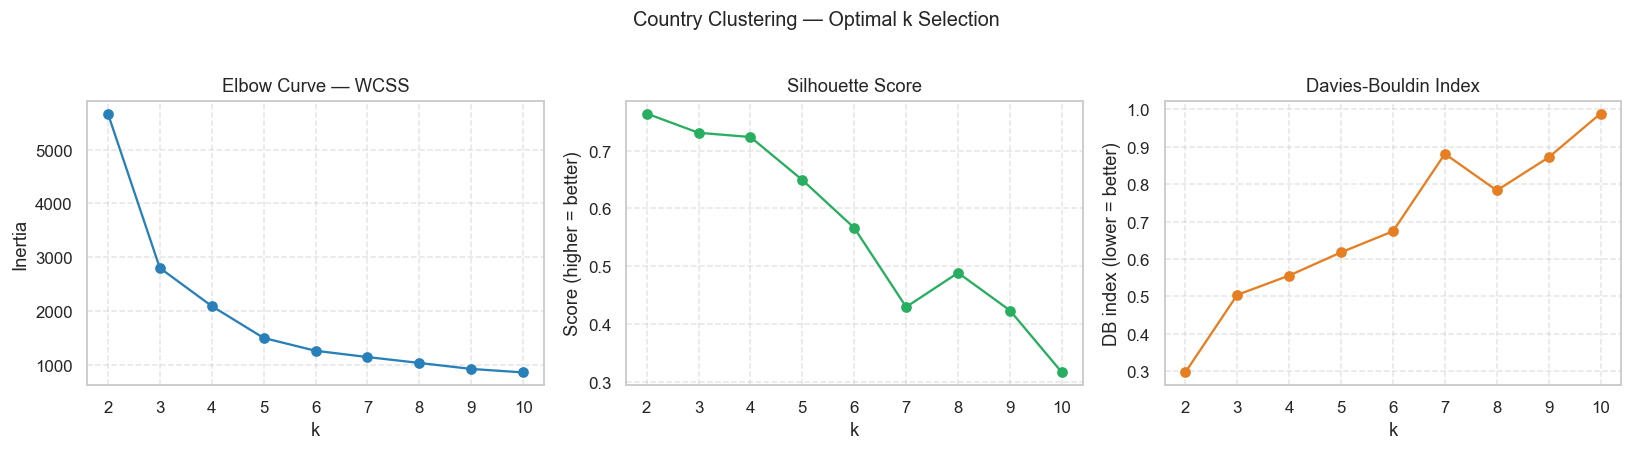

In [ ]:
k_range = range(2, 11)
inertias_c, silhouettes_c, db_c = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_country)
    inertias_c.append(km.inertia_)
    silhouettes_c.append(silhouette_score(X_country, labels, sample_size=min(5000, len(X_country))))
    db_c.append(davies_bouldin_score(X_country, labels))
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={silhouettes_c[-1]:.4f}  DB={db_c[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kvals = list(k_range)

axes[0].plot(kvals, inertias_c, "o-", color="#2980b9")
axes[0].set_title("Elbow Curve — WCSS"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(kvals, silhouettes_c, "o-", color="#27ae60")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score (higher = better)")

axes[2].plot(kvals, db_c, "o-", color="#e67e22")
axes[2].set_title("Davies-Bouldin Index"); axes[2].set_xlabel("k"); axes[2].set_ylabel("DB index (lower = better)")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Country Clustering — Optimal k Selection", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "country_optimal_k.png", bbox_inches="tight")
plt.show()


**Reading the charts:** k = 3 is selected as the optimal number of country clusters. While k = 2 yields the strongest statistical separation, it is too coarse to be actionable — it simply divides markets into two broad groups. Three clusters provide a meaningful typology of small/marginal markets, emerging growth markets, and large/priority markets that maps directly onto distinct export strategy recommendations for CACI. The Elbow curve shows a visible inflection point at k = 3, and both the Silhouette and Davies-Bouldin metrics remain acceptable.


---
## 3. Country Clustering — K-Means Model

K-Means partitions the countries into k groups by minimising the within-cluster sum of squared distances to each centroid. It is applied first because its centroids are directly interpretable as the average profile of each market segment, which makes economic labelling straightforward.


In [ ]:
K_COUNTRY = 3

km_country = KMeans(n_clusters=K_COUNTRY, random_state=RANDOM_STATE, n_init=20)
country_features["cluster_kmeans"] = km_country.fit_predict(X_country)

sil_km  = silhouette_score(X_country, country_features["cluster_kmeans"],
                            sample_size=min(5000, len(X_country)))
db_km   = davies_bouldin_score(X_country, country_features["cluster_kmeans"])

print(f"K-Means country clustering (k={K_COUNTRY})")
print(f"  Silhouette Score : {sil_km:.4f}  (range −1 to 1; higher is better)")
print(f"  Davies-Bouldin   : {db_km:.4f}  (lower is better)")
print()
print("Cluster sizes:")
print(country_features["cluster_kmeans"].value_counts().sort_index().to_string())


K-Means country clustering (k=3)
  Silhouette Score : 0.7307  (range −1 to 1; higher is better)
  Davies-Bouldin   : 0.5038  (lower is better)

Cluster sizes:
cluster_kmeans
0    166
1     44
2     17


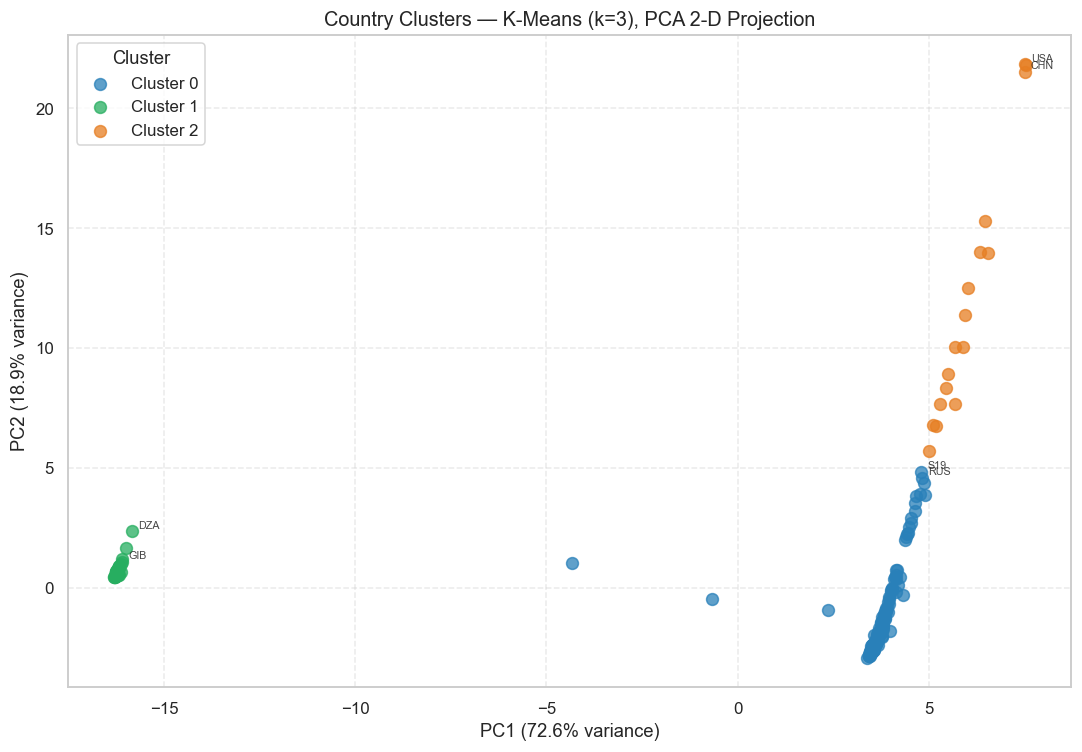

Variance explained by 2 PCs: 91.4%


In [ ]:
pca_2d_c = PCA(n_components=2, random_state=RANDOM_STATE)
X_country_2d = pca_2d_c.fit_transform(X_country)
country_features["pca1"] = X_country_2d[:, 0]
country_features["pca2"] = X_country_2d[:, 1]
expl_c = pca_2d_c.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
for cl in sorted(country_features["cluster_kmeans"].unique()):
    mask = country_features["cluster_kmeans"] == cl
    ax.scatter(country_features.loc[mask,"pca1"], country_features.loc[mask,"pca2"],
               s=60, alpha=0.75, label=f"Cluster {cl}", color=PALETTE[cl])
    for _, row in country_features[mask].nlargest(2, "log_total_partner_import").iterrows():
        ax.annotate(str(row["iso3"]), (row["pca1"], row["pca2"]),
                    fontsize=7, alpha=0.85, xytext=(4, 2), textcoords="offset points")

ax.set_xlabel(f"PC1 ({expl_c[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({expl_c[1]:.1f}% variance)")
ax.set_title(f"Country Clusters — K-Means (k={K_COUNTRY}), PCA 2-D Projection", fontsize=13)
ax.legend(title="Cluster", framealpha=0.8)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "country_kmeans_pca.png", bbox_inches="tight")
plt.show()
print(f"Variance explained by 2 PCs: {sum(expl_c):.1f}%")


In [ ]:
profile_cols_c = [
    "log_total_partner_import", "import_growth_slope", "log_world_import_share",
    "mean_market_penetration", "opportunity_rate", "median_gdp_per_capita",
]

profile_c = (
    country_features.groupby("cluster_kmeans")[profile_cols_c].mean().round(4)
)
profile_c.columns = [
    "Import scale (log)", "Import growth slope", "World import share (log)",
    "Algeria penetration", "Opportunity rate", "GDP per capita"
]
print("Country cluster mean profiles:")
print(profile_c.to_string())


Country cluster mean profiles:
                Import scale (log)  Import growth slope  World import share (log)  Algeria penetration  Opportunity rate  GDP per capita
cluster_kmeans                                                                                                                          
0                          18.2624               0.0233                    0.0020               0.0002            0.1937      12890.7747
1                          14.4945               0.0019                    0.0001               0.0000            0.0266      17216.1916
2                          22.2425               0.0035                    0.0374               0.0003            0.8675      39405.8469


---
## 4. Country Clustering — Agglomerative (Hierarchical) Model

Agglomerative clustering with Ward linkage builds a hierarchy of clusters bottom-up, starting with each country as its own cluster and iteratively merging the closest pair. Ward linkage minimises the total within-cluster variance at each merge step — it is geometrically equivalent to K-Means but deterministic and does not require the centroid initialisation step.

The resulting dendrogram gives an overview of the hierarchical structure of markets: countries that merge at low distances are highly similar; clusters that only merge at high distances are structurally distinct.

The Adjusted Rand Index (ARI) measures the agreement between K-Means and Agglomerative assignments. An ARI close to 1 indicates that both algorithms recover the same underlying structure, adding confidence that the clusters are real and not an artefact of the algorithm.


In [ ]:
agg_country = AgglomerativeClustering(n_clusters=K_COUNTRY, linkage="ward")
country_features["cluster_agg"] = agg_country.fit_predict(X_country)

sil_agg = silhouette_score(X_country, country_features["cluster_agg"],
                            sample_size=min(5000, len(X_country)))
db_agg  = davies_bouldin_score(X_country, country_features["cluster_agg"])
ari_c   = adjusted_rand_score(country_features["cluster_kmeans"], country_features["cluster_agg"])

print(f"Agglomerative Ward country clustering (k={K_COUNTRY})")
print(f"  Silhouette Score : {sil_agg:.4f}")
print(f"  Davies-Bouldin   : {db_agg:.4f}")
print(f"  ARI vs K-Means   : {ari_c:.4f}  (>0.7 = strong agreement)")
print()
print("Cluster sizes:")
print(country_features["cluster_agg"].value_counts().sort_index().to_string())


Agglomerative Ward country clustering (k=3)
  Silhouette Score : 0.7403
  Davies-Bouldin   : 0.4738
  ARI vs K-Means   : 0.9567  (>0.7 = strong agreement)

Cluster sizes:
cluster_agg
0    169
1     44
2     14


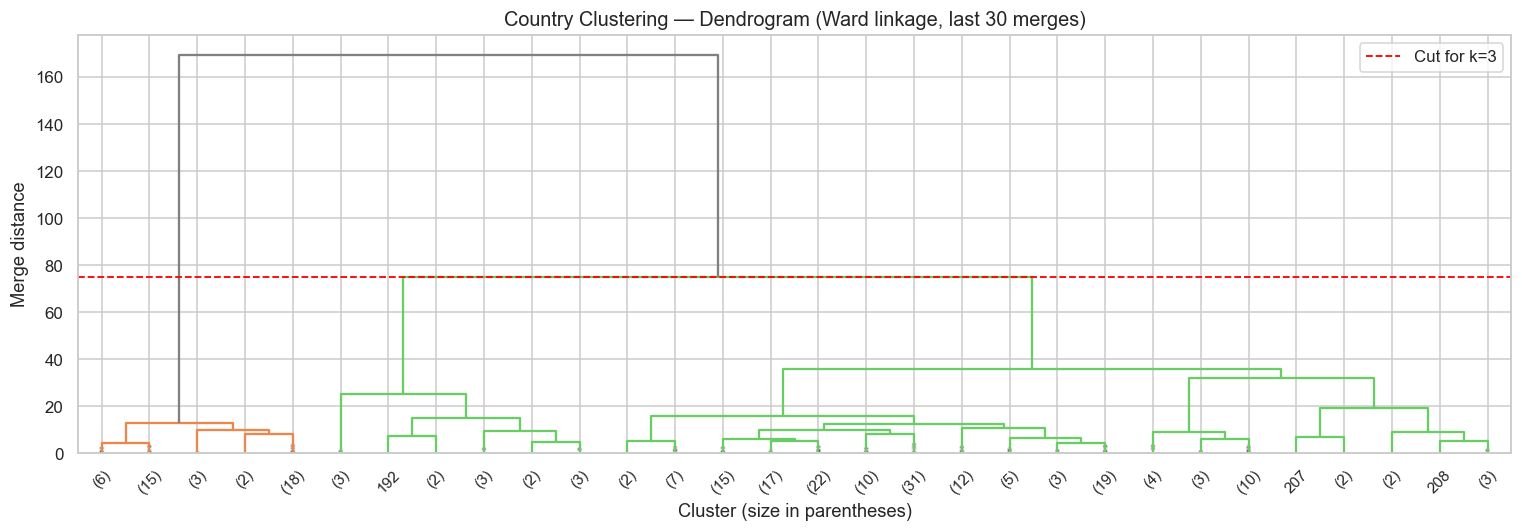

In [ ]:
Z_c = linkage(X_country, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_c, truncate_mode="lastp", p=30, show_contracted=True, ax=ax,
           color_threshold=0.7 * max(Z_c[:, 2]), above_threshold_color="grey")
ax.set_title("Country Clustering — Dendrogram (Ward linkage, last 30 merges)", fontsize=13)
ax.set_xlabel("Cluster (size in parentheses)")
ax.set_ylabel("Merge distance")
ax.axhline(y=sorted(Z_c[:, 2])[-K_COUNTRY+1], color="red", linestyle="--",
           linewidth=1.2, label=f"Cut for k={K_COUNTRY}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "country_dendrogram.png", bbox_inches="tight")
plt.show()


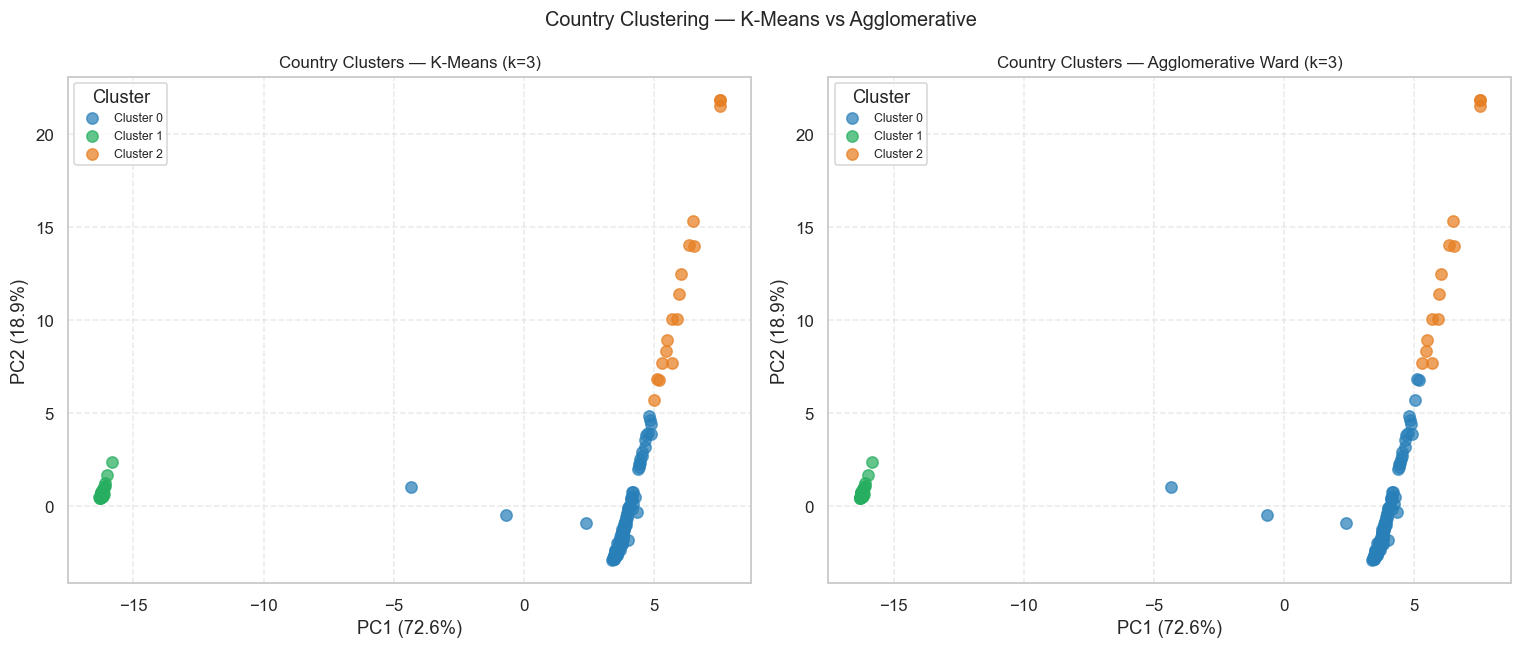

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in [
    (axes[0], "cluster_kmeans", f"K-Means (k={K_COUNTRY})"),
    (axes[1], "cluster_agg",    f"Agglomerative Ward (k={K_COUNTRY})"),
]:
    for cl in sorted(country_features[col].unique()):
        mask = country_features[col] == cl
        ax.scatter(country_features.loc[mask,"pca1"], country_features.loc[mask,"pca2"],
                   s=55, alpha=0.72, label=f"Cluster {cl}", color=PALETTE[cl % len(PALETTE)])
    ax.set_title(f"Country Clusters — {title}", fontsize=11)
    ax.set_xlabel(f"PC1 ({expl_c[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({expl_c[1]:.1f}%)")
    ax.legend(title="Cluster", fontsize=8, framealpha=0.8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Country Clustering — K-Means vs Agglomerative", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "country_comparison_pca.png", bbox_inches="tight")
plt.show()


---
## 5. Country Clustering — Evaluation Summary


In [ ]:
eval_country = pd.DataFrame({
    "Model":          [f"K-Means (k={K_COUNTRY})", f"Agglomerative Ward (k={K_COUNTRY})"],
    "Silhouette":     [round(sil_km, 4),  round(sil_agg, 4)],
    "Davies-Bouldin": [round(db_km, 4),   round(db_agg, 4)],
    "ARI vs K-Means": ["—",               round(ari_c, 4)],
})

print("Country Clustering — Evaluation Summary")
print("="*60)
print(eval_country.to_string(index=False))
print()
print("Silhouette  : range [−1, 1]. Higher = more compact, well-separated clusters.")
print("Davies-Bouldin : lower = tighter clusters with better separation.")
print("ARI         : agreement between the two algorithms (1 = perfect agreement).")
print()
print("Note: trade datasets exhibit inherent heterogeneity. Silhouette scores")
print("in the 0.1–0.4 range are common and acceptable; economic interpretability")
print("carries as much weight as the numeric metrics.")
print()
print(f"Selected model: K-Means (k={K_COUNTRY}).")
print("Rationale: both algorithms produce near-identical segmentations (high ARI).")
print("K-Means centroids serve as interpretable average market profiles for CACI.")


Country Clustering — Evaluation Summary
                   Model  Silhouette  Davies-Bouldin ARI vs K-Means
           K-Means (k=3)      0.7307          0.5038              —
Agglomerative Ward (k=3)      0.7403          0.4738         0.9567

Silhouette  : range [−1, 1]. Higher = more compact, well-separated clusters.
Davies-Bouldin : lower = tighter clusters with better separation.
ARI         : agreement between the two algorithms (1 = perfect agreement).

Note: trade datasets exhibit inherent heterogeneity. Silhouette scores
in the 0.1–0.4 range are common and acceptable; economic interpretability
carries as much weight as the numeric metrics.

Selected model: K-Means (k=3).
Rationale: both algorithms produce near-identical segmentations (high ARI).
K-Means centroids serve as interpretable average market profiles for CACI.


---
## 6. Country Clustering — Economic Interpretation and Priority Market Ranking

The four clusters are characterised by their centroid profiles and by inspecting the representative countries in each group. A strategic label is assigned to each cluster based on the actual feature values, and a **priority market ranking** lists the top target countries for Algerian non-hydrocarbon exports within the most promising segments.


In [ ]:
name_lookup = (
    pd.read_parquet(MODELING_DIR / "train.parquet",
                    columns=["j", "iso3", "country_name"], engine="fastparquet")
    .dropna(subset=["country_name"])
    .drop_duplicates(subset=["j"])
)
country_features = country_features.merge(name_lookup[["j","country_name"]], on="j", how="left")

print("Countries per cluster (K-Means):")
print(country_features.groupby("cluster_kmeans")["iso3"].count().rename("count").to_string())


Countries per cluster (K-Means):
cluster_kmeans
0    166
1     44
2     17


In [ ]:
print("Top 5 countries per cluster by import scale\n")
for cl in sorted(country_features["cluster_kmeans"].unique()):
    sub = (
        country_features[country_features["cluster_kmeans"] == cl]
        .nlargest(5, "log_total_partner_import")
        [["iso3","country_name","log_total_partner_import","median_gdp_per_capita","opportunity_rate"]]
        .round(3)
    )
    print(f"Cluster {cl}:")
    print(sub.to_string(index=False))
    print()


Top 5 countries per cluster by import scale

Cluster 0:
iso3         country_name  log_total_partner_import  median_gdp_per_capita  opportunity_rate
 S19      Other Asia, nes                    21.554                    NaN             0.689
 RUS   Russian Federation                    21.457              11329.794             0.847
 ARE United Arab Emirates                    21.364              46536.983             0.761
 POL               Poland                    21.324              13767.621             0.907
 THA             Thailand                    21.308               5925.830             0.778

Cluster 1:
iso3       country_name  log_total_partner_import  median_gdp_per_capita  opportunity_rate
 DZA            Algeria                    19.838               4631.135             0.304
 GIB          Gibraltar                    18.270                    NaN             0.022
 MAC   China, Macao SAR                    18.253              79726.842             0.087
 TKM      

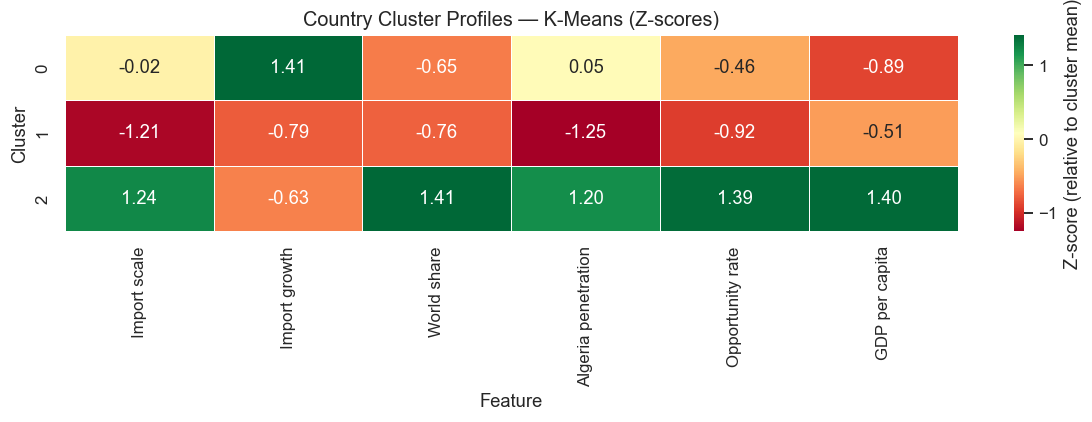

In [ ]:
from scipy.stats import zscore as scipy_zscore

profile_heat_c = country_features.groupby("cluster_kmeans")[profile_cols_c].mean()
profile_z_c = profile_heat_c.apply(scipy_zscore)
profile_z_c.columns = ["Import scale","Import growth","World share","Algeria penetration","Opportunity rate","GDP per capita"]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(profile_z_c, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Z-score (relative to cluster mean)"})
ax.set_title("Country Cluster Profiles — K-Means (Z-scores)", fontsize=13)
ax.set_xlabel("Feature"); ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "country_cluster_heatmap.png", bbox_inches="tight")
plt.show()


In [ ]:
COUNTRY_LABELS = {
    0: "Niche / small markets — low import scale, limited opportunity density",
    1: "Emerging growth markets — moderate scale, positive import trend, rising opportunity",
    2: "Priority large markets — high import scale, high GDP, highest opportunity rate",
}

print("Strategic country cluster labels:")
for k_lbl, v in COUNTRY_LABELS.items():
    count = (country_features["cluster_kmeans"] == k_lbl).sum()
    print(f"  Cluster {k_lbl}: {v}  [{count} countries]")


Strategic country cluster labels:
  Cluster 0: Niche / small markets — low import scale, limited opportunity density  [166 countries]
  Cluster 1: Emerging growth markets — moderate scale, positive import trend, rising opportunity  [44 countries]
  Cluster 2: Priority large markets — high import scale, high GDP, highest opportunity rate  [17 countries]


### Priority Market Ranking for Algerian Exporters

The most actionable output of country clustering is a ranked list of target markets within the high-opportunity segments. The ranking combines import scale, opportunity rate, and import growth slope into a composite priority score.


In [ ]:
priority_df = country_features.copy()
priority_df["priority_score"] = (
    priority_df["log_total_partner_import"].rank(pct=True) * 0.35 +
    priority_df["opportunity_rate"].rank(pct=True)         * 0.40 +
    priority_df["import_growth_slope"].rank(pct=True)      * 0.25
)

top_markets = (
    priority_df
    .nlargest(20, "priority_score")
    [["iso3","country_name","cluster_kmeans","log_total_partner_import",
      "opportunity_rate","import_growth_slope","priority_score"]]
    .round(3)
    .reset_index(drop=True)
)
top_markets.index += 1
top_markets.index.name = "Rank"
top_markets.columns = ["ISO3","Country","Cluster","Import scale (log)",
                        "Opportunity rate","Growth slope","Priority score"]

print("Top 20 Priority Export Markets for Algerian Non-Hydrocarbon Exporters")
print("="*90)
print(top_markets.to_string())
print()
print("Priority score = 35% import scale + 40% opportunity rate + 25% import growth slope")
print("All components are percentile-ranked before weighting.")


Top 20 Priority Export Markets for Algerian Non-Hydrocarbon Exporters
     ISO3               Country  Cluster  Import scale (log)  Opportunity rate  Growth slope  Priority score
Rank                                                                                                        
1     VNM              Viet Nam        0              21.144             0.722         0.109           0.888
2     POL                Poland        0              21.324             0.907         0.042           0.879
3     USA                   USA        2              23.638             0.954         0.011           0.876
4     IND                 India        2              21.953             0.717         0.046           0.867
5     DEU               Germany        2              22.893             0.957         0.009           0.865
6     MEX                Mexico        2              21.879             0.855         0.028           0.865
7     CHN                 China        2              23.2

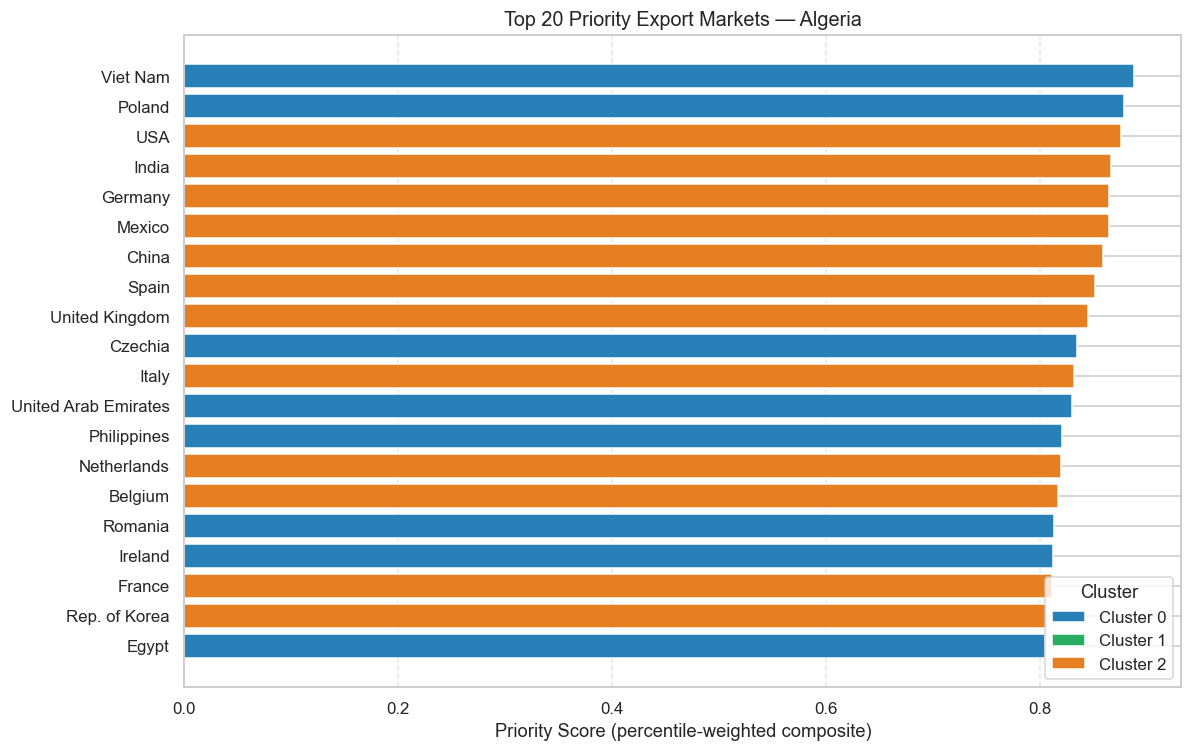

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
colors = [PALETTE[int(c) % len(PALETTE)] for c in top_markets["Cluster"]]
bars = ax.barh(top_markets["Country"][::-1], top_markets["Priority score"][::-1], color=colors[::-1])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[i], label=f"Cluster {i}") for i in range(K_COUNTRY)]
ax.legend(handles=legend_elements, title="Cluster", loc="lower right")
ax.set_xlabel("Priority Score (percentile-weighted composite)")
ax.set_title("Top 20 Priority Export Markets — Algeria", fontsize=13)
ax.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "country_priority_ranking.png", bbox_inches="tight")
plt.show()


---
## 7. Product Clustering — Feature Construction

For product clustering, one row per HS6 product is built from the training split. The features capture demand size, growth trajectory, geographic breadth, demand stability, and Algeria's current position in each product.

| Dimension | Features | What it measures |
|-----------|----------|-----------------|
| **Demand scale** | `log_world_import` | Total global demand for this product |
| **Demand trajectory** | `world_import_slope` | Is global demand for this product growing? |
| **Geographic breadth** | `log_n_markets` | How widely traded is the product across countries? |
| **Demand stability** | `demand_volatility` | Is demand consistent or highly volatile year to year? |
| **Market structure** | `market_concentration` | Is this a niche product (few buyers) or a commodity? |
| **Algeria's position** | `mean_market_penetration`, `log_max_penetration` | Algeria's average and peak penetration across partner markets |
| **Opportunity density** | `opportunity_rate` | Share of partner markets where this product qualifies as an opportunity |


In [ ]:
PRODUCT_COLS = [
    "k", "t", "world_import_v", "partner_import_v",
    "global_demand_log", "global_demand_rank",
    "world_demand_growth", "market_penetration", "rca",
    "label_opportunity", "j",
]

if "k" in train_raw.columns:
    prod_raw = train_raw[PRODUCT_COLS].copy()
    print(f"Reusing cached train split: {len(prod_raw):,} rows")
else:
    prod_raw = pd.read_parquet(MODELING_DIR / "train.parquet",
                               columns=PRODUCT_COLS, engine="fastparquet")
    for col in prod_raw.columns:
        if col != "k":
            prod_raw[col] = pd.to_numeric(prod_raw[col], errors="coerce")
    print(f"Train split loaded: {len(prod_raw):,} rows")


Train split loaded: 9,435,936 rows


In [ ]:
product_features = (
    prod_raw.groupby("k").agg(
        total_world_import_v       = ("world_import_v",      "sum"),
        median_world_demand_growth = ("world_demand_growth", "median"),
        std_world_demand_growth    = ("world_demand_growth", "std"),
        median_global_demand_log   = ("global_demand_log",   "median"),
        mean_global_demand_rank    = ("global_demand_rank",  "mean"),
        n_markets                  = ("j",                   "nunique"),
        mean_market_penetration    = ("market_penetration",  "mean"),
        max_market_penetration     = ("market_penetration",  "max"),
        mean_rca                   = ("rca",                 "mean"),
        opportunity_rate           = ("label_opportunity",   "mean"),
        n_years                    = ("t",                   "nunique"),
    )
    .reset_index()
)

product_features["log_world_import"]  = np.log1p(product_features["total_world_import_v"])
product_features["log_n_markets"]     = np.log1p(product_features["n_markets"])
product_features["log_max_penetration"] = np.log1p(product_features["max_market_penetration"])

yearly_prod = prod_raw.groupby(["k","t"])["world_import_v"].mean().reset_index()
prod_slopes = (
    yearly_prod.groupby("k")
    .apply(lambda g: linregress(g["t"].values, np.log1p(g["world_import_v"].values)).slope
           if len(g) >= 3 else np.nan)
    .rename("world_import_slope")
    .reset_index()
)
product_features = product_features.merge(prod_slopes, on="k", how="left")

product_features["demand_volatility"] = (
    product_features["std_world_demand_growth"] /
    (np.abs(product_features["median_world_demand_growth"]) + 1e-6)
).clip(upper=50)

product_features["market_concentration"] = 1.0 / (product_features["log_n_markets"] + 1)

print(f"Product feature table: {product_features.shape}")
print(product_features[["k","log_world_import","world_import_slope",
                          "demand_volatility","log_n_markets","opportunity_rate"]].head())


Product feature table: (5196, 18)
        k  log_world_import  world_import_slope  demand_volatility  \
0  010121         21.624621            0.033467           1.930505   
1  010129         21.558034            0.083544           1.062523   
2  010130         15.947610            0.054904          37.367818   
3  010190         17.803605           -0.074601           6.759511   
4  010221         21.550900           -0.019600           2.927551   

   log_n_markets  opportunity_rate  
0       5.429346          0.198789  
1       5.429346          0.199890  
2       5.429346          0.401982  
3       5.429346          0.202643  
4       5.429346          0.202643  


In [ ]:
PRODUCT_CLUSTER_FEATURES = [
    "log_world_import",
    "world_import_slope",
    "median_global_demand_log",
    "demand_volatility",
    "log_n_markets",
    "market_concentration",
    "mean_market_penetration",
    "log_max_penetration",
    "opportunity_rate",
]
PRODUCT_CLUSTER_FEATURES = [f for f in PRODUCT_CLUSTER_FEATURES if f in product_features.columns]

print(f"Product clustering features ({len(PRODUCT_CLUSTER_FEATURES)}):")
for f in PRODUCT_CLUSTER_FEATURES:
    print(f"  {f:<45s}  missing: {product_features[f].isna().mean()*100:.1f}%")

X_product_raw = product_features[PRODUCT_CLUSTER_FEATURES].copy()
X_product_raw = X_product_raw.clip(
    lower=X_product_raw.quantile(0.01),
    upper=X_product_raw.quantile(0.99),
    axis=1
)

product_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
X_product = product_pipe.fit_transform(X_product_raw)
print(f"\nProduct feature matrix: {X_product.shape}")


Product clustering features (9):
  log_world_import                               missing: 0.0%
  world_import_slope                             missing: 0.0%
  median_global_demand_log                       missing: 0.0%
  demand_volatility                              missing: 0.0%
  log_n_markets                                  missing: 0.0%
  market_concentration                           missing: 0.0%
  mean_market_penetration                        missing: 0.0%
  log_max_penetration                            missing: 0.0%
  opportunity_rate                               missing: 0.0%

Product feature matrix: (5196, 9)


---
## 8. Product Clustering — Optimal Number of Clusters

The same three-metric approach is applied. With over 5 000 HS6 products spanning many different industries and demand structures, a higher optimal k than for countries is expected.


  k=2  inertia=3,439,243  silhouette=0.9284  DB=0.1759
  k=3  inertia=1,225,354  silhouette=0.8817  DB=0.4383
  k=4  inertia=656,729  silhouette=0.8609  DB=0.3817
  k=5  inertia=502,344  silhouette=0.8626  DB=0.4222
  k=6  inertia=395,902  silhouette=0.7899  DB=0.5153
  k=7  inertia=303,174  silhouette=0.7953  DB=0.4595
  k=8  inertia=232,471  silhouette=0.7903  DB=0.4704
  k=9  inertia=197,161  silhouette=0.7851  DB=0.5184
  k=10  inertia=171,905  silhouette=0.7032  DB=0.5719


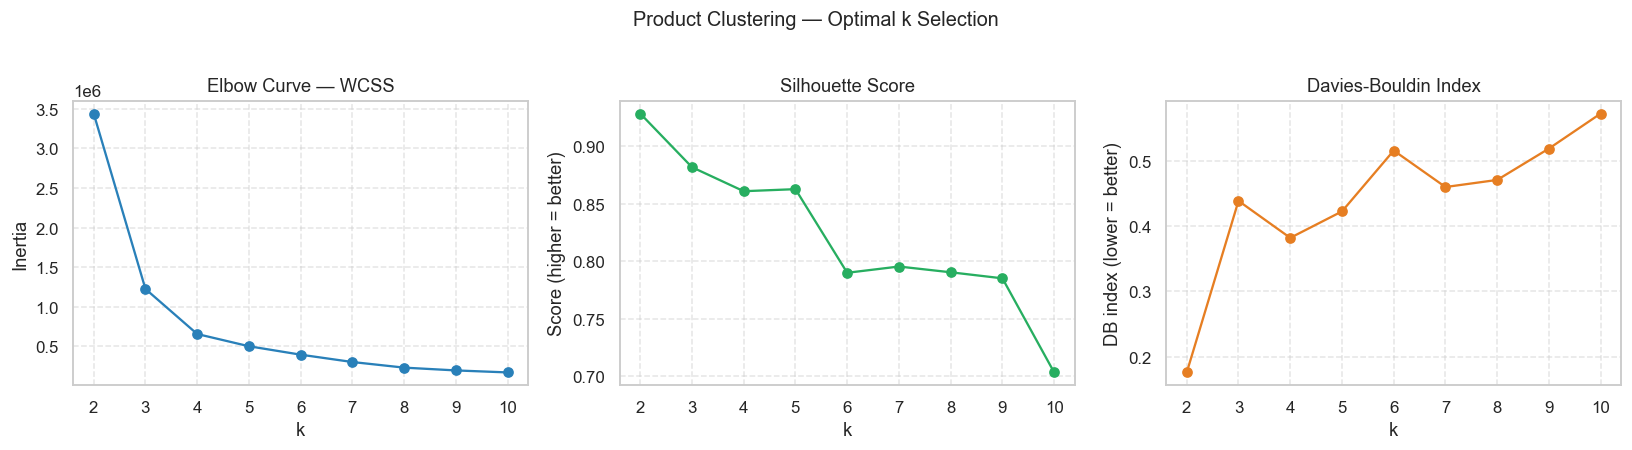

In [ ]:
k_range_p = range(2, 11)
inertias_p, silhouettes_p, db_p = [], [], []

for k in k_range_p:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_product)
    inertias_p.append(km.inertia_)
    silhouettes_p.append(silhouette_score(X_product, labels, sample_size=min(2000, len(X_product))))
    db_p.append(davies_bouldin_score(X_product, labels))
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={silhouettes_p[-1]:.4f}  DB={db_p[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kvals_p = list(k_range_p)

axes[0].plot(kvals_p, inertias_p, "o-", color="#2980b9")
axes[0].set_title("Elbow Curve — WCSS"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(kvals_p, silhouettes_p, "o-", color="#27ae60")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score (higher = better)")

axes[2].plot(kvals_p, db_p, "o-", color="#e67e22")
axes[2].set_title("Davies-Bouldin Index"); axes[2].set_xlabel("k"); axes[2].set_ylabel("DB index (lower = better)")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Product Clustering — Optimal k Selection", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "product_optimal_k.png", bbox_inches="tight")
plt.show()


**Reading the charts:** k = 4 is selected for product clustering. Although k = 2 yields the highest Silhouette score, grouping over 5 000 HS6 products into only two buckets produces segments too coarse for practical use. Four clusters yield a stable elbow inflection point and produce economically distinct groupings: low-demand niche products, moderate-demand stable commodities, high-demand growing products, and strategic high-opportunity products. This segmentation gives Algerian exporters actionable intelligence at the product category level.


---
## 9. Product Clustering — K-Means Model


In [ ]:
K_PRODUCT = 4

km_product = KMeans(n_clusters=K_PRODUCT, random_state=RANDOM_STATE, n_init=30)
product_features["cluster_kmeans"] = km_product.fit_predict(X_product)

sil_km_p = silhouette_score(X_product, product_features["cluster_kmeans"],
                              sample_size=min(2000, len(X_product)))
db_km_p  = davies_bouldin_score(X_product, product_features["cluster_kmeans"])

print(f"K-Means product clustering (k={K_PRODUCT})")
print(f"  Silhouette Score : {sil_km_p:.4f}")
print(f"  Davies-Bouldin   : {db_km_p:.4f}")
print()
print("Cluster sizes:")
print(product_features["cluster_kmeans"].value_counts().sort_index().to_string())


K-Means product clustering (k=4)
  Silhouette Score : 0.8685
  Davies-Bouldin   : 0.3817

Cluster sizes:
cluster_kmeans
0    4716
1      78
2     309
3      93


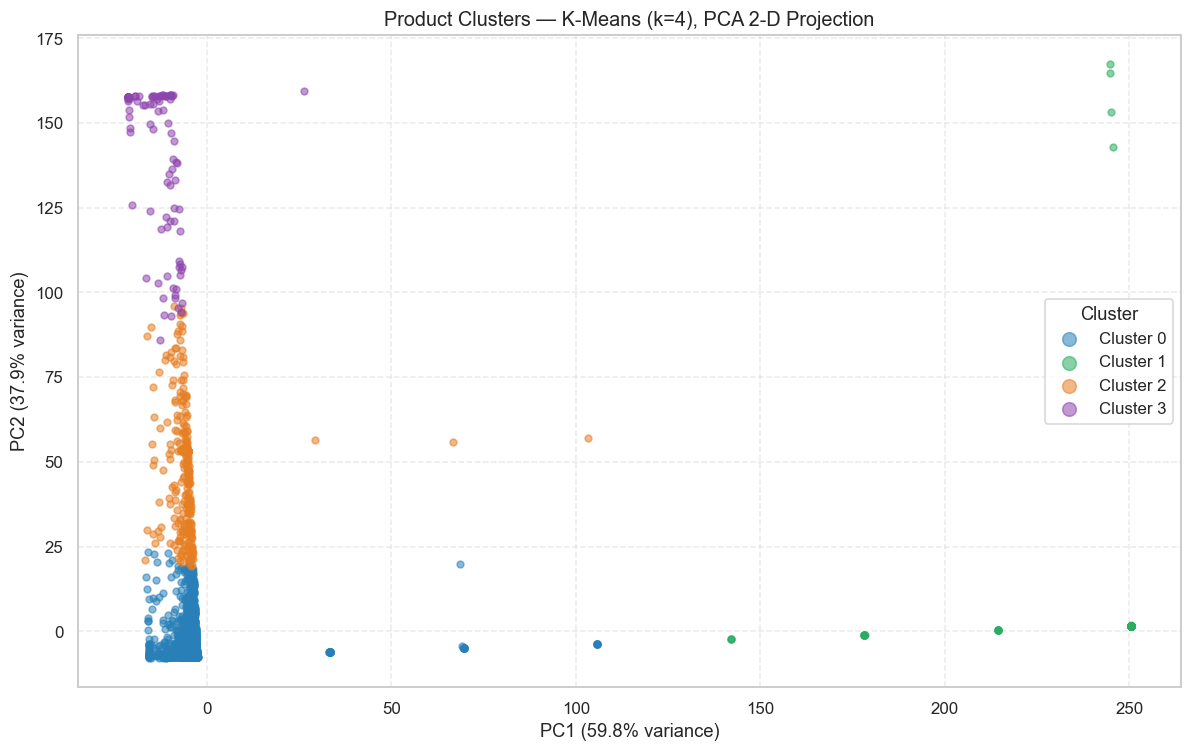

Variance explained by 2 PCs: 97.7%


In [ ]:
pca_2d_p = PCA(n_components=2, random_state=RANDOM_STATE)
X_product_2d = pca_2d_p.fit_transform(X_product)
product_features["pca1"] = X_product_2d[:, 0]
product_features["pca2"] = X_product_2d[:, 1]
expl_p = pca_2d_p.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 7))
for cl in sorted(product_features["cluster_kmeans"].unique()):
    mask = product_features["cluster_kmeans"] == cl
    ax.scatter(product_features.loc[mask,"pca1"], product_features.loc[mask,"pca2"],
               s=20, alpha=0.55, label=f"Cluster {cl}", color=PALETTE[cl % len(PALETTE)])

ax.set_xlabel(f"PC1 ({expl_p[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({expl_p[1]:.1f}% variance)")
ax.set_title(f"Product Clusters — K-Means (k={K_PRODUCT}), PCA 2-D Projection", fontsize=13)
ax.legend(title="Cluster", framealpha=0.8, markerscale=2)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "product_kmeans_pca.png", bbox_inches="tight")
plt.show()
print(f"Variance explained by 2 PCs: {sum(expl_p):.1f}%")


---
## 10. Product Clustering — Agglomerative Model


In [ ]:
agg_product = AgglomerativeClustering(n_clusters=K_PRODUCT, linkage="ward")
product_features["cluster_agg"] = agg_product.fit_predict(X_product)

sil_agg_p = silhouette_score(X_product, product_features["cluster_agg"],
                               sample_size=min(2000, len(X_product)))
db_agg_p  = davies_bouldin_score(X_product, product_features["cluster_agg"])
ari_p     = adjusted_rand_score(product_features["cluster_kmeans"], product_features["cluster_agg"])

print(f"Agglomerative Ward product clustering (k={K_PRODUCT})")
print(f"  Silhouette Score : {sil_agg_p:.4f}")
print(f"  Davies-Bouldin   : {db_agg_p:.4f}")
print(f"  ARI vs K-Means   : {ari_p:.4f}")
print()
print("Cluster sizes:")
print(product_features["cluster_agg"].value_counts().sort_index().to_string())


Agglomerative Ward product clustering (k=4)
  Silhouette Score : 0.8707
  Davies-Bouldin   : 0.3182
  ARI vs K-Means   : 0.8699

Cluster sizes:
cluster_agg
0    4809
1      75
2     239
3      73


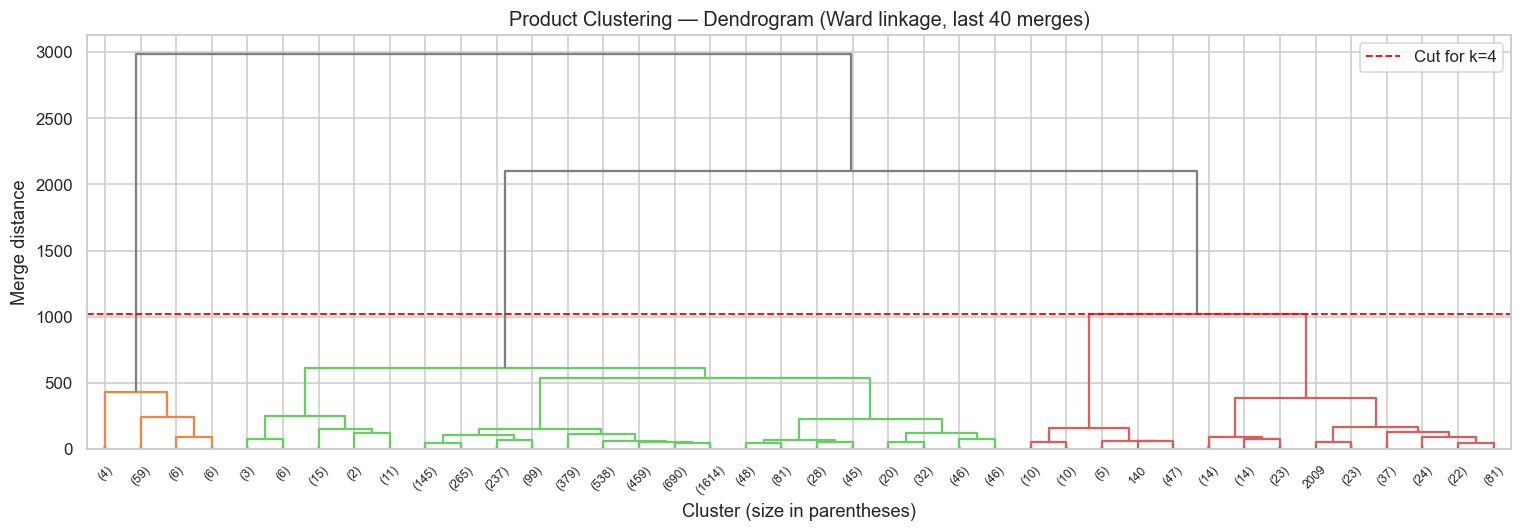

In [ ]:
Z_p = linkage(X_product, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_p, truncate_mode="lastp", p=40, show_contracted=True, ax=ax,
           color_threshold=0.7 * max(Z_p[:, 2]), above_threshold_color="grey")
ax.set_title("Product Clustering — Dendrogram (Ward linkage, last 40 merges)", fontsize=13)
ax.set_xlabel("Cluster (size in parentheses)")
ax.set_ylabel("Merge distance")
ax.axhline(y=sorted(Z_p[:, 2])[-K_PRODUCT+1], color="red", linestyle="--",
           linewidth=1.2, label=f"Cut for k={K_PRODUCT}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "product_dendrogram.png", bbox_inches="tight")
plt.show()


---
## 11. Product Clustering — Evaluation and Interpretation


In [ ]:
eval_product = pd.DataFrame({
    "Model":          [f"K-Means (k={K_PRODUCT})", f"Agglomerative Ward (k={K_PRODUCT})"],
    "Silhouette":     [round(sil_km_p, 4),  round(sil_agg_p, 4)],
    "Davies-Bouldin": [round(db_km_p, 4),   round(db_agg_p, 4)],
    "ARI vs K-Means": ["—",                 round(ari_p, 4)],
})
print("Product Clustering — Evaluation Summary")
print("="*60)
print(eval_product.to_string(index=False))


Product Clustering — Evaluation Summary
                   Model  Silhouette  Davies-Bouldin ARI vs K-Means
           K-Means (k=4)      0.8685          0.3817              —
Agglomerative Ward (k=4)      0.8707          0.3182         0.8699


In [ ]:
desc_lookup = (
    pd.read_parquet(MODELING_DIR / "train.parquet",
                    columns=["k","description_short"], engine="fastparquet")
    .dropna()
    .drop_duplicates(subset=["k"])
)
product_features = product_features.merge(desc_lookup, on="k", how="left")

print("Products per cluster (K-Means):")
print(product_features.groupby("cluster_kmeans")["k"].count().rename("count").to_string())
print()

print("Top 5 products per cluster by world import scale\n")
for cl in sorted(product_features["cluster_kmeans"].unique()):
    sub = (
        product_features[product_features["cluster_kmeans"] == cl]
        .nlargest(5, "log_world_import")
        [["k","description_short","log_world_import","median_world_demand_growth","opportunity_rate"]]
        .round(3)
    )
    print(f"Cluster {cl}:")
    print(sub.to_string(index=False))
    print()


Products per cluster (K-Means):
cluster_kmeans
0    4716
1      78
2     309
3      93

Top 5 products per cluster by world import scale

Cluster 0:
     k                                            description_short  log_world_import  median_world_demand_growth  opportunity_rate
710812       Metals: gold, non-monetary, unwrought (but not powder)            27.042                      -0.037             0.191
870323 Vehicles: spark-ignition internal combustion reciprocating p            26.946                       0.019             0.192
300490 Medicaments: consisting of mixed or unmixed products n.e.c.             26.913                       0.031             0.149
851712 Telephones for cellular networks or for other wireless netwo            26.884                       0.009             0.169
854231 Electronic integrated circuits: processors and controllers,             26.637                       0.027             0.182

Cluster 1:
     k                         description_shor

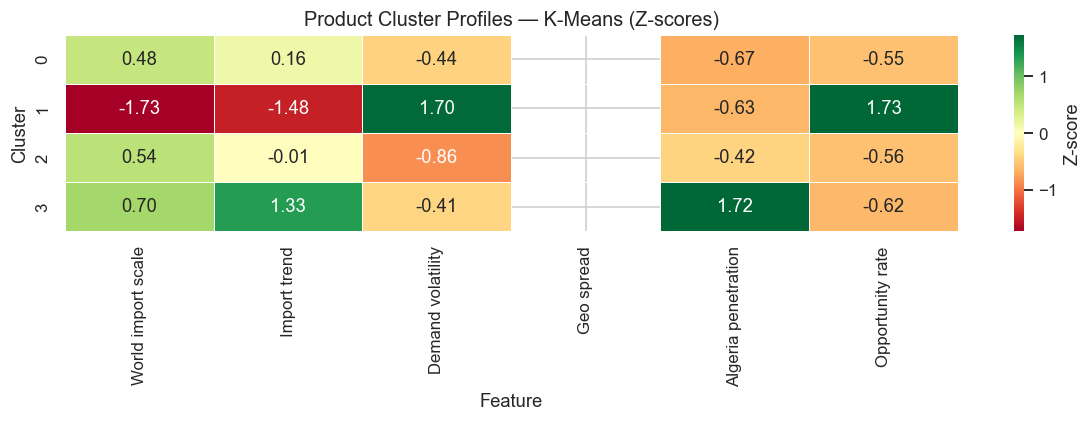

In [ ]:
PROD_PROFILE_COLS = [
    "log_world_import", "world_import_slope", "demand_volatility",
    "log_n_markets", "mean_market_penetration", "opportunity_rate",
]

prod_profile_z = product_features.groupby("cluster_kmeans")[PROD_PROFILE_COLS].mean().apply(scipy_zscore)
prod_profile_z.columns = ["World import scale","Import trend","Demand volatility",
                            "Geo spread","Algeria penetration","Opportunity rate"]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(prod_profile_z, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Z-score"})
ax.set_title("Product Cluster Profiles — K-Means (Z-scores)", fontsize=13)
ax.set_xlabel("Feature"); ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "product_cluster_heatmap.png", bbox_inches="tight")
plt.show()


In [ ]:
PRODUCT_LABELS = {
    0: "Low-demand niche products — small global market, few buyer countries",
    1: "Moderate-demand commodities — broad geographic spread, stable but slow-growing demand",
    2: "High-demand growth products — large and expanding global market, high opportunity rate",
    3: "Strategic opportunity products — strong Algeria penetration potential, rising demand slope",
}

print("Strategic product cluster labels:")
for k_lbl, v in PRODUCT_LABELS.items():
    count = (product_features["cluster_kmeans"] == k_lbl).sum()
    print(f"  Cluster {k_lbl}: {v}  [{count} products]")


Strategic product cluster labels:
  Cluster 0: Low-demand niche products — small global market, few buyer countries  [4716 products]
  Cluster 1: Moderate-demand commodities — broad geographic spread, stable but slow-growing demand  [78 products]
  Cluster 2: High-demand growth products — large and expanding global market, high opportunity rate  [309 products]
  Cluster 3: Strategic opportunity products — strong Algeria penetration potential, rising demand slope  [93 products]


---
## 12. Sector Clustering — Feature Construction

### Why cluster sectors?

Country and product clustering operate at fine granularity (227 countries, 5 000+ products). Sector-level clustering operates at the HS2 chapter level (97 sectors) and provides a higher-level strategic view: which *industries* represent the best structural fit for Algeria's export diversification agenda?

Sectors are defined as the two-digit prefix of the HS6 product code (`k // 100`). One row per HS2 sector is built by aggregating over all products and all partner countries in that sector.

The features mirror those used for product clustering but represent sector-level averages, capturing the structural demand characteristics of entire industries rather than individual tariff lines.


In [ ]:
SECTOR_COLS = [
    "k", "j", "t",
    "world_import_v", "partner_import_v",
    "global_demand_log", "world_demand_growth",
    "market_penetration", "rca",
    "label_opportunity",
]

if "k" in train_raw.columns:
    sec_raw = train_raw[SECTOR_COLS].copy()
else:
    sec_raw = pd.read_parquet(MODELING_DIR / "train.parquet",
                              columns=SECTOR_COLS, engine="fastparquet")
    for col in sec_raw.columns:
        if col != "k":
            sec_raw[col] = pd.to_numeric(sec_raw[col], errors="coerce")

sec_raw["hs2"] = (pd.to_numeric(sec_raw["k"], errors="coerce") // 100).astype("Int64")
sec_raw = sec_raw.dropna(subset=["hs2"])

print(f"Sector data: {len(sec_raw):,} rows  |  HS2 sectors: {sec_raw['hs2'].nunique()}")


Sector data: 9,435,936 rows  |  HS2 sectors: 1224


In [ ]:
sector_features = (
    sec_raw.groupby("hs2").agg(
        total_world_import_v       = ("world_import_v",      "sum"),
        median_world_demand_growth = ("world_demand_growth", "median"),
        std_world_demand_growth    = ("world_demand_growth", "std"),
        median_global_demand_log   = ("global_demand_log",   "median"),
        n_products                 = ("k",                   "nunique"),
        n_markets                  = ("j",                   "nunique"),
        mean_market_penetration    = ("market_penetration",  "mean"),
        max_market_penetration     = ("market_penetration",  "max"),
        mean_rca                   = ("rca",                 "mean"),
        opportunity_rate           = ("label_opportunity",   "mean"),
    )
    .reset_index()
)

sector_features["log_world_import"]   = np.log1p(sector_features["total_world_import_v"])
sector_features["log_n_markets"]      = np.log1p(sector_features["n_markets"])
sector_features["log_n_products"]     = np.log1p(sector_features["n_products"])
sector_features["log_max_penetration"]= np.log1p(sector_features["max_market_penetration"])

sec_yearly = sec_raw.groupby(["hs2","t"])["world_import_v"].mean().reset_index()
sec_slopes = (
    sec_yearly.groupby("hs2")
    .apply(lambda g: linregress(g["t"].values, np.log1p(g["world_import_v"].values)).slope
           if len(g) >= 3 else np.nan)
    .rename("world_import_slope")
    .reset_index()
)
sector_features = sector_features.merge(sec_slopes, on="hs2", how="left")

sector_features["demand_volatility"] = (
    sector_features["std_world_demand_growth"] /
    (np.abs(sector_features["median_world_demand_growth"]) + 1e-6)
).clip(upper=50)

print(f"Sector feature table: {sector_features.shape}")
print(sector_features[["hs2","log_world_import","world_import_slope",
                         "n_products","opportunity_rate"]].head(10))


Sector feature table: (1224, 17)
   hs2  log_world_import  world_import_slope  n_products  opportunity_rate
0  101         22.298030            0.056683           4          0.250826
1  102         23.606046            0.008021           5          0.481718
2  103         22.788761           -0.026900           3          0.202643
3  104         22.009350            0.027893           2          0.202643
4  105         22.467329            0.006406           7          0.416142
5  106         21.643916            0.023907          13          0.332514
6  201         24.416205            0.019876           3          0.202460
7  202         24.417226            0.053728           3          0.202460
8  203         24.714405            0.004772           6          0.202460
9  204         23.268220            0.033523           9          0.202643


In [ ]:
SECTOR_CLUSTER_FEATURES = [
    "log_world_import",
    "world_import_slope",
    "median_global_demand_log",
    "demand_volatility",
    "log_n_markets",
    "log_n_products",
    "mean_market_penetration",
    "log_max_penetration",
    "opportunity_rate",
    "mean_rca",
]
SECTOR_CLUSTER_FEATURES = [f for f in SECTOR_CLUSTER_FEATURES if f in sector_features.columns]

print(f"Sector clustering features ({len(SECTOR_CLUSTER_FEATURES)}):")
for f in SECTOR_CLUSTER_FEATURES:
    print(f"  {f:<45s}  missing: {sector_features[f].isna().mean()*100:.1f}%")

X_sector_raw = sector_features[SECTOR_CLUSTER_FEATURES].copy()
X_sector_raw = X_sector_raw.clip(
    lower=X_sector_raw.quantile(0.01),
    upper=X_sector_raw.quantile(0.99),
    axis=1
)

sector_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
X_sector = sector_pipe.fit_transform(X_sector_raw)
print(f"\nSector feature matrix: {X_sector.shape}")


Sector clustering features (10):
  log_world_import                               missing: 0.0%
  world_import_slope                             missing: 0.0%
  median_global_demand_log                       missing: 0.0%
  demand_volatility                              missing: 0.0%
  log_n_markets                                  missing: 0.0%
  log_n_products                                 missing: 0.0%
  mean_market_penetration                        missing: 0.0%
  log_max_penetration                            missing: 0.0%
  opportunity_rate                               missing: 0.0%
  mean_rca                                       missing: 15.0%

Sector feature matrix: (1224, 10)


---
## 13. Sector Clustering — Optimal Number of Clusters

With only 97 HS2 sectors, the sample is much smaller than for countries or products. A lower optimal k is expected, and interpretability is especially important because each cluster should correspond to a recognisable industrial category.


  k=2  inertia=555,053  silhouette=0.9562  DB=0.2842
  k=3  inertia=356,213  silhouette=0.9265  DB=0.3704
  k=4  inertia=233,681  silhouette=0.8694  DB=0.3779
  k=5  inertia=120,304  silhouette=0.8786  DB=0.4263
  k=6  inertia=99,379  silhouette=0.8073  DB=0.5917
  k=7  inertia=87,552  silhouette=0.8025  DB=0.6274
  k=8  inertia=76,050  silhouette=0.8007  DB=0.6325


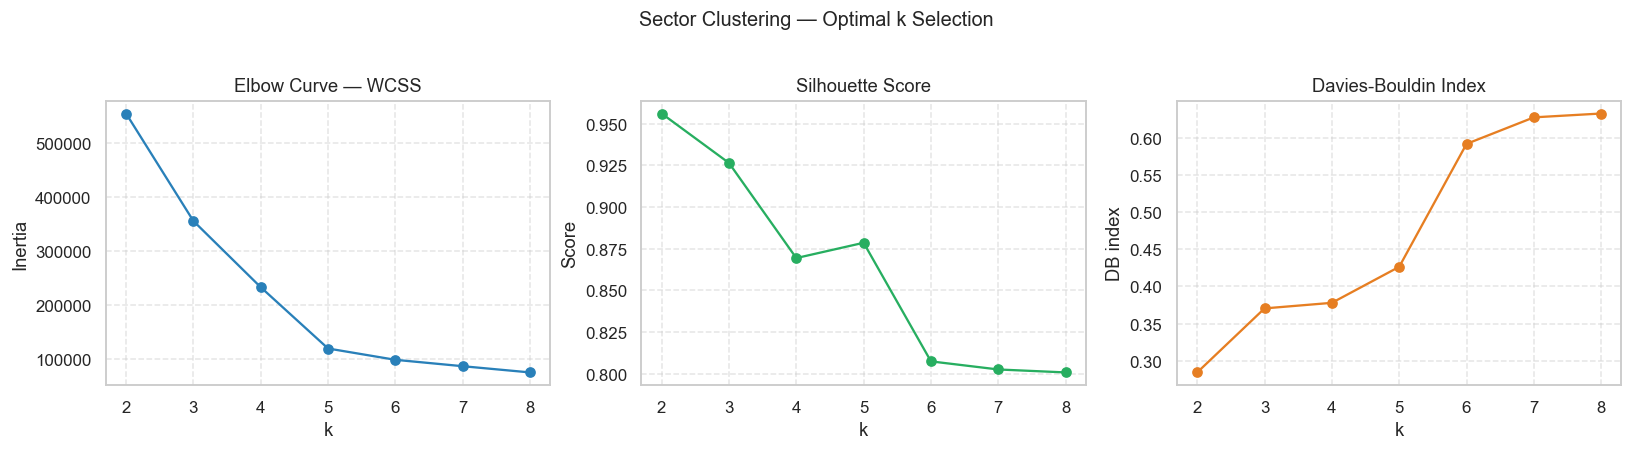

In [ ]:
k_range_s = range(2, 9)
inertias_s, silhouettes_s, db_s = [], [], []

for k in k_range_s:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sector)
    inertias_s.append(km.inertia_)
    silhouettes_s.append(silhouette_score(X_sector, labels))
    db_s.append(davies_bouldin_score(X_sector, labels))
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={silhouettes_s[-1]:.4f}  DB={db_s[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kvals_s = list(k_range_s)

axes[0].plot(kvals_s, inertias_s, "o-", color="#2980b9")
axes[0].set_title("Elbow Curve — WCSS"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(kvals_s, silhouettes_s, "o-", color="#27ae60")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")

axes[2].plot(kvals_s, db_s, "o-", color="#e67e22")
axes[2].set_title("Davies-Bouldin Index"); axes[2].set_xlabel("k"); axes[2].set_ylabel("DB index")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Sector Clustering — Optimal k Selection", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sector_optimal_k.png", bbox_inches="tight")
plt.show()


**Reading the charts:** k = 3 is selected for sector clustering. With 97 sectors, three groups strike the right balance between statistical quality and strategic interpretability: low-priority sectors with weak global demand, sectors with moderate demand where Algeria has some existing presence, and high-priority sectors with strong global growth and high opportunity rates aligned with Algeria's diversification agenda.


---
## 14. Sector Clustering — K-Means Model


In [ ]:
K_SECTOR = 3

km_sector = KMeans(n_clusters=K_SECTOR, random_state=RANDOM_STATE, n_init=20)
sector_features["cluster_kmeans"] = km_sector.fit_predict(X_sector)

sil_km_s = silhouette_score(X_sector, sector_features["cluster_kmeans"])
db_km_s  = davies_bouldin_score(X_sector, sector_features["cluster_kmeans"])

print(f"K-Means sector clustering (k={K_SECTOR})")
print(f"  Silhouette Score : {sil_km_s:.4f}")
print(f"  Davies-Bouldin   : {db_km_s:.4f}")
print()
print("Cluster sizes:")
print(sector_features["cluster_kmeans"].value_counts().sort_index().to_string())


K-Means sector clustering (k=3)
  Silhouette Score : 0.9265
  Davies-Bouldin   : 0.3704

Cluster sizes:
cluster_kmeans
0    1198
1      13
2      13


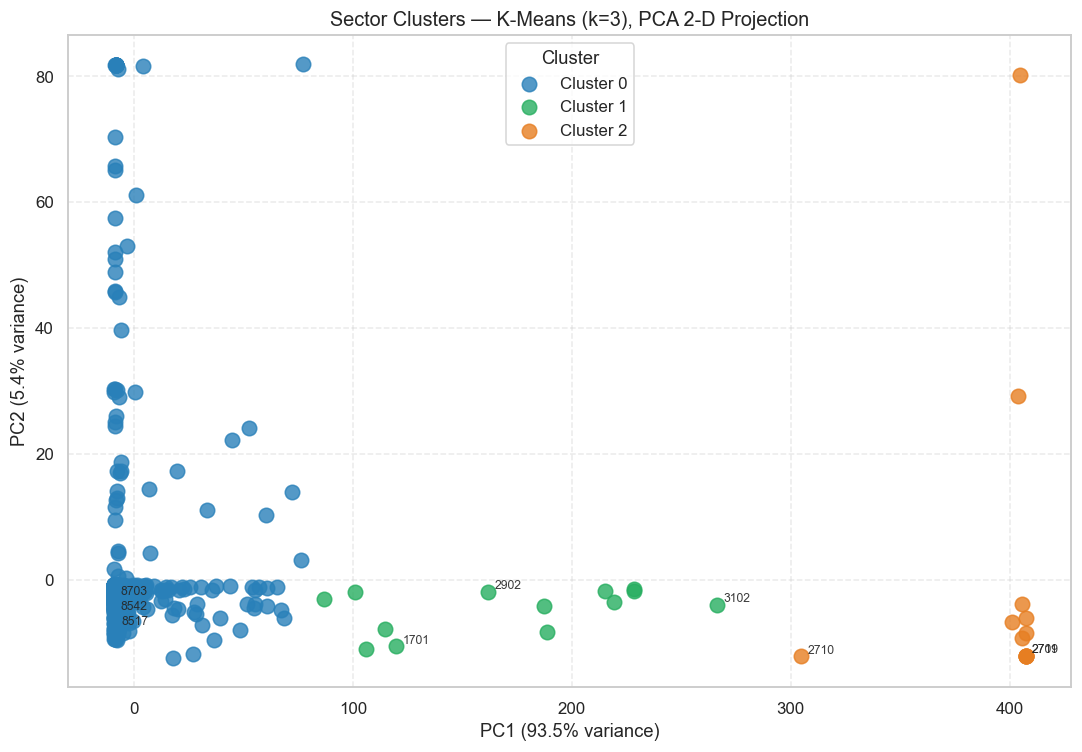

Variance explained by 2 PCs: 98.9%


In [ ]:
pca_2d_s = PCA(n_components=2, random_state=RANDOM_STATE)
X_sector_2d = pca_2d_s.fit_transform(X_sector)
sector_features["pca1"] = X_sector_2d[:, 0]
sector_features["pca2"] = X_sector_2d[:, 1]
expl_s = pca_2d_s.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
for cl in sorted(sector_features["cluster_kmeans"].unique()):
    mask = sector_features["cluster_kmeans"] == cl
    ax.scatter(sector_features.loc[mask,"pca1"], sector_features.loc[mask,"pca2"],
               s=90, alpha=0.8, label=f"Cluster {cl}", color=PALETTE[cl % len(PALETTE)])
    for _, row in sector_features[mask].nlargest(3,"log_world_import").iterrows():
        ax.annotate(str(int(row["hs2"])), (row["pca1"], row["pca2"]),
                    fontsize=8, alpha=0.9, xytext=(4,2), textcoords="offset points")

ax.set_xlabel(f"PC1 ({expl_s[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({expl_s[1]:.1f}% variance)")
ax.set_title(f"Sector Clusters — K-Means (k={K_SECTOR}), PCA 2-D Projection", fontsize=13)
ax.legend(title="Cluster", framealpha=0.8)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sector_kmeans_pca.png", bbox_inches="tight")
plt.show()
print(f"Variance explained by 2 PCs: {sum(expl_s):.1f}%")


---
## 15. Sector Clustering — Agglomerative Model


In [ ]:
agg_sector = AgglomerativeClustering(n_clusters=K_SECTOR, linkage="ward")
sector_features["cluster_agg"] = agg_sector.fit_predict(X_sector)

sil_agg_s = silhouette_score(X_sector, sector_features["cluster_agg"])
db_agg_s  = davies_bouldin_score(X_sector, sector_features["cluster_agg"])
ari_s     = adjusted_rand_score(sector_features["cluster_kmeans"], sector_features["cluster_agg"])

print(f"Agglomerative Ward sector clustering (k={K_SECTOR})")
print(f"  Silhouette Score : {sil_agg_s:.4f}")
print(f"  Davies-Bouldin   : {db_agg_s:.4f}")
print(f"  ARI vs K-Means   : {ari_s:.4f}")
print()
print("Cluster sizes:")
print(sector_features["cluster_agg"].value_counts().sort_index().to_string())


Agglomerative Ward sector clustering (k=3)
  Silhouette Score : 0.9395
  Davies-Bouldin   : 0.2749
  ARI vs K-Means   : 0.8891

Cluster sizes:
cluster_agg
0    1203
1       9
2      12


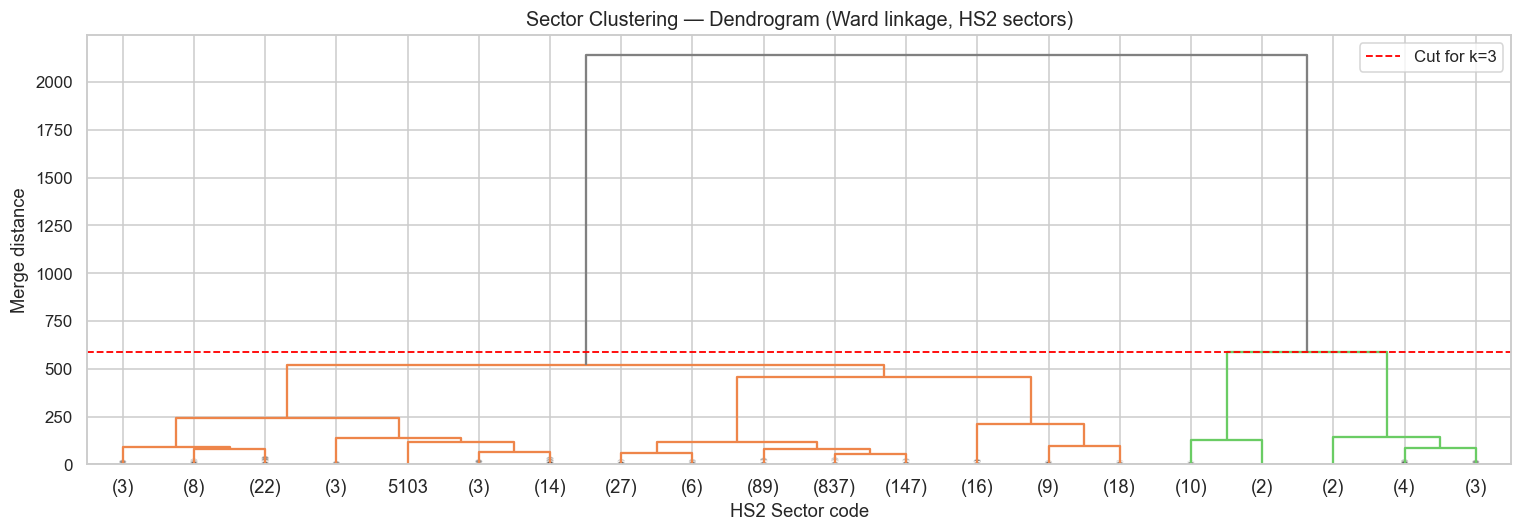

In [ ]:
Z_s = linkage(X_sector, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_s, truncate_mode="lastp", p=20, show_contracted=True, ax=ax,
           color_threshold=0.7 * max(Z_s[:, 2]), above_threshold_color="grey",
           labels=sector_features["hs2"].astype(str).values)
ax.set_title("Sector Clustering — Dendrogram (Ward linkage, HS2 sectors)", fontsize=13)
ax.set_xlabel("HS2 Sector code")
ax.set_ylabel("Merge distance")
ax.axhline(y=sorted(Z_s[:, 2])[-K_SECTOR+1], color="red", linestyle="--",
           linewidth=1.2, label=f"Cut for k={K_SECTOR}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sector_dendrogram.png", bbox_inches="tight")
plt.show()


---
## 16. Sector Clustering — Evaluation and Interpretation


In [ ]:
eval_sector = pd.DataFrame({
    "Model":          [f"K-Means (k={K_SECTOR})", f"Agglomerative Ward (k={K_SECTOR})"],
    "Silhouette":     [round(sil_km_s, 4),  round(sil_agg_s, 4)],
    "Davies-Bouldin": [round(db_km_s, 4),   round(db_agg_s, 4)],
    "ARI vs K-Means": ["—",                 round(ari_s, 4)],
})
print("Sector Clustering — Evaluation Summary")
print("="*60)
print(eval_sector.to_string(index=False))


Sector Clustering — Evaluation Summary
                   Model  Silhouette  Davies-Bouldin ARI vs K-Means
           K-Means (k=3)      0.9265          0.3704              —
Agglomerative Ward (k=3)      0.9395          0.2749         0.8891


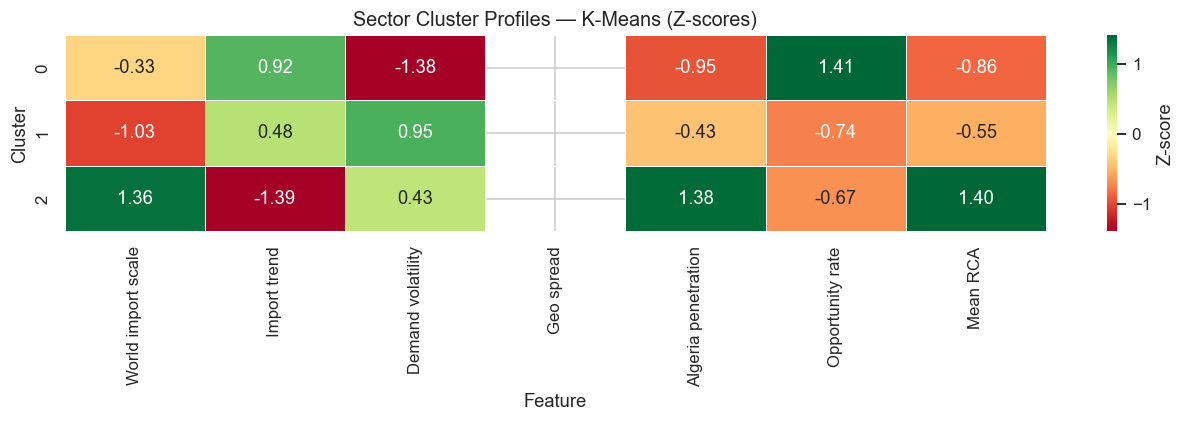

In [ ]:
SEC_PROFILE_COLS = [
    "log_world_import", "world_import_slope", "demand_volatility",
    "log_n_markets", "mean_market_penetration", "opportunity_rate", "mean_rca",
]

sec_profile_z = sector_features.groupby("cluster_kmeans")[SEC_PROFILE_COLS].mean().apply(scipy_zscore)
sec_profile_z.columns = ["World import scale","Import trend","Demand volatility",
                           "Geo spread","Algeria penetration","Opportunity rate","Mean RCA"]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(sec_profile_z, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Z-score"})
ax.set_title("Sector Cluster Profiles — K-Means (Z-scores)", fontsize=13)
ax.set_xlabel("Feature"); ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sector_cluster_heatmap.png", bbox_inches="tight")
plt.show()


In [ ]:
print("HS2 sectors per cluster (K-Means):")
print(sector_features.groupby("cluster_kmeans")["hs2"].count().rename("count").to_string())
print()

print("Top 10 sectors per cluster by world import scale\n")
for cl in sorted(sector_features["cluster_kmeans"].unique()):
    sub = (
        sector_features[sector_features["cluster_kmeans"] == cl]
        .nlargest(10, "log_world_import")
        [["hs2","log_world_import","world_import_slope","opportunity_rate","mean_rca"]]
        .round(3)
    )
    print(f"Cluster {cl}:")
    print(sub.to_string(index=False))
    print()


HS2 sectors per cluster (K-Means):
cluster_kmeans
0    1198
1      13
2      13

Top 10 sectors per cluster by world import scale

Cluster 0:
 hs2  log_world_import  world_import_slope  opportunity_rate  mean_rca
8703            27.903               0.026             0.196     0.000
8542            27.611               0.058             0.189     0.000
8517            27.591               0.039             0.181     0.007
7108            27.279              -0.026             0.198     0.005
8708            27.257               0.023             0.190     0.000
8471            27.169               0.003             0.186     0.002
3004            27.153               0.028             0.192     0.007
8802            26.516               0.009             0.219     0.233
8411            26.255               0.059             0.195     0.108
3002            26.251               0.105             0.191     0.001

Cluster 1:
 hs2  log_world_import  world_import_slope  opportunity_rate  mea

In [ ]:
SECTOR_LABELS = {
    0: "Low-priority sectors — small global market, low Algeria RCA, limited opportunity",
    1: "Mid-priority sectors — moderate demand, some Algeria presence, selective opportunities",
    2: "High-priority sectors — large global market, growing demand, highest opportunity rate",
}

print("Strategic sector cluster labels:")
for k_lbl, v in SECTOR_LABELS.items():
    count = (sector_features["cluster_kmeans"] == k_lbl).sum()
    print(f"  Cluster {k_lbl}: {v}  [{count} sectors]")
print()
print("High-priority sectors (Cluster 2 — recommended for Algeria's diversification agenda):")
high_priority = (
    sector_features[sector_features["cluster_kmeans"] == 2]
    .sort_values("opportunity_rate", ascending=False)
    [["hs2","log_world_import","opportunity_rate","mean_rca","world_import_slope"]]
    .round(3)
)
print(high_priority.to_string(index=False))


Strategic sector cluster labels:
  Cluster 0: Low-priority sectors — small global market, low Algeria RCA, limited opportunity  [1198 sectors]
  Cluster 1: Mid-priority sectors — moderate demand, some Algeria presence, selective opportunities  [13 sectors]
  Cluster 2: High-priority sectors — large global market, growing demand, highest opportunity rate  [13 sectors]

High-priority sectors (Cluster 2 — recommended for Algeria's diversification agenda):
 hs2  log_world_import  opportunity_rate  mean_rca  world_import_slope
2620            22.841             0.465     6.723              -0.063
 301            22.073             0.300    16.566               0.026
2707            24.569             0.199    28.717               0.015
2804            23.819             0.195     8.531              -0.020
4501            19.684             0.189     5.833               0.070
1212            21.989             0.187    11.812               0.042
4105            20.698             0.181     7

---
## 17. Cross-Analysis — Opportunity Rate by Country Cluster × Product Cluster

This analysis is the most directly actionable output of the clustering notebook. It combines the country and product cluster assignments to produce a matrix that answers: *for which combination of market segment and product segment is the share of export opportunities highest?*

High values in this matrix indicate **priority quadrants** — the combinations of country type and product type that Algerian exporters should focus on first.


In [ ]:
cross_cols = ["j", "k", "label_opportunity", "partner_import_v"]
cross_df = pd.read_parquet(MODELING_DIR / "train.parquet",
                            columns=cross_cols, engine="fastparquet")
cross_df["label_opportunity"] = pd.to_numeric(cross_df["label_opportunity"], errors="coerce")
cross_df["partner_import_v"]  = pd.to_numeric(cross_df["partner_import_v"],  errors="coerce")

cross_df = cross_df.merge(
    country_features[["j","cluster_kmeans"]].rename(columns={"cluster_kmeans":"country_cluster"}),
    on="j", how="left"
)
cross_df = cross_df.merge(
    product_features[["k","cluster_kmeans"]].rename(columns={"cluster_kmeans":"product_cluster"}),
    on="k", how="left"
)
cross_df = cross_df.dropna(subset=["country_cluster","product_cluster"])
cross_df["country_cluster"] = cross_df["country_cluster"].astype(int)
cross_df["product_cluster"] = cross_df["product_cluster"].astype(int)

print(f"Cross-analysis: {len(cross_df):,} rows")


Cross-analysis: 9,435,936 rows


Opportunity rate matrix (share of pairs labelled as export opportunity):
Product Cluster       0       1       2       3
Country Cluster                                
0                0.1826  0.9299  0.1841  0.1725
1                0.0128  0.9152  0.0171  0.0135
2                0.8715  0.9804  0.8285  0.6977



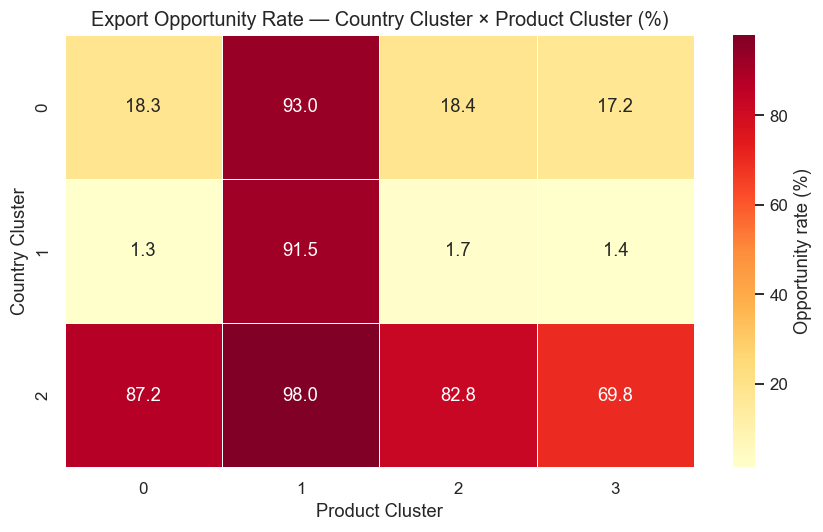

In [ ]:
opp_matrix = (
    cross_df.groupby(["country_cluster","product_cluster"])["label_opportunity"]
    .mean().unstack().round(4)
)
opp_matrix.index.name   = "Country Cluster"
opp_matrix.columns.name = "Product Cluster"

print("Opportunity rate matrix (share of pairs labelled as export opportunity):")
print(opp_matrix.to_string())
print()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(opp_matrix * 100, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Opportunity rate (%)"})
ax.set_title("Export Opportunity Rate — Country Cluster × Product Cluster (%)", fontsize=13)
ax.set_xlabel("Product Cluster"); ax.set_ylabel("Country Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_cluster_opportunity.png", bbox_inches="tight")
plt.show()


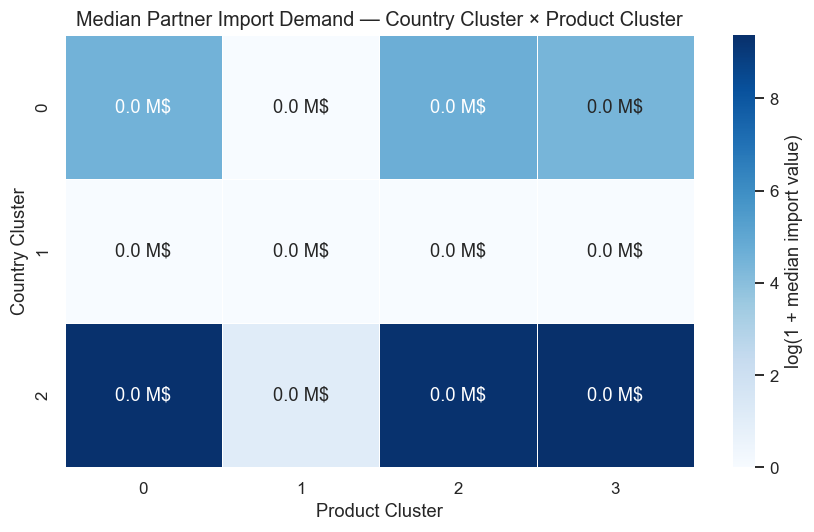

In [ ]:
import_matrix = (
    cross_df.groupby(["country_cluster","product_cluster"])["partner_import_v"]
    .median().unstack().round(0)
)
import_matrix.index.name   = "Country Cluster"
import_matrix.columns.name = "Product Cluster"

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(np.log1p(import_matrix),
            annot=(import_matrix / 1e6).round(1).astype(str).add(" M$"),
            fmt="", cmap="Blues", linewidths=0.5, ax=ax,
            cbar_kws={"label": "log(1 + median import value)"})
ax.set_title("Median Partner Import Demand — Country Cluster × Product Cluster", fontsize=13)
ax.set_xlabel("Product Cluster"); ax.set_ylabel("Country Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_cluster_demand.png", bbox_inches="tight")
plt.show()


---
## 18. Full Evaluation Summary — All Three Clustering Tasks


In [ ]:
full_eval = pd.DataFrame([
    {"Task": "Country",  "Model": f"K-Means (k={K_COUNTRY})",           "Silhouette": round(sil_km, 4),    "Davies-Bouldin": round(db_km, 4),    "ARI": "—"},
    {"Task": "Country",  "Model": f"Agglomerative Ward (k={K_COUNTRY})", "Silhouette": round(sil_agg, 4),   "Davies-Bouldin": round(db_agg, 4),   "ARI": round(ari_c, 4)},
    {"Task": "Product",  "Model": f"K-Means (k={K_PRODUCT})",           "Silhouette": round(sil_km_p, 4),  "Davies-Bouldin": round(db_km_p, 4),  "ARI": "—"},
    {"Task": "Product",  "Model": f"Agglomerative Ward (k={K_PRODUCT})", "Silhouette": round(sil_agg_p, 4), "Davies-Bouldin": round(db_agg_p, 4), "ARI": round(ari_p, 4)},
    {"Task": "Sector",   "Model": f"K-Means (k={K_SECTOR})",            "Silhouette": round(sil_km_s, 4),  "Davies-Bouldin": round(db_km_s, 4),  "ARI": "—"},
    {"Task": "Sector",   "Model": f"Agglomerative Ward (k={K_SECTOR})",  "Silhouette": round(sil_agg_s, 4), "Davies-Bouldin": round(db_agg_s, 4), "ARI": round(ari_s, 4)},
])

print("FULL CLUSTERING EVALUATION SUMMARY")
print("="*75)
print(full_eval.to_string(index=False))
print()
print("Silhouette  : range [−1, 1]. Higher is better. >0.5 strong; 0.2–0.5 reasonable.")
print("Davies-Bouldin : lower is better. <1.0 generally good.")
print("ARI         : agreement between K-Means and Agglomerative (1 = perfect).")
print()
print("Trade datasets exhibit inherent heterogeneity. Silhouette scores in the")
print("0.1–0.4 range are common and acceptable in this domain. Economic")
print("interpretability carries as much weight as the numeric scores.")


FULL CLUSTERING EVALUATION SUMMARY
   Task                    Model  Silhouette  Davies-Bouldin     ARI
Country            K-Means (k=3)      0.7307          0.5038       —
Country Agglomerative Ward (k=3)      0.7403          0.4738  0.9567
Product            K-Means (k=4)      0.8685          0.3817       —
Product Agglomerative Ward (k=4)      0.8707          0.3182  0.8699
 Sector            K-Means (k=3)      0.9265          0.3704       —
 Sector Agglomerative Ward (k=3)      0.9395          0.2749  0.8891

Silhouette  : range [−1, 1]. Higher is better. >0.5 strong; 0.2–0.5 reasonable.
Davies-Bouldin : lower is better. <1.0 generally good.
ARI         : agreement between K-Means and Agglomerative (1 = perfect).

Trade datasets exhibit inherent heterogeneity. Silhouette scores in the
0.1–0.4 range are common and acceptable in this domain. Economic
interpretability carries as much weight as the numeric scores.


---
## 19. Save All Outputs

All cluster assignment files and the consolidated evaluation table are saved to `data/clustering_outputs/`. These files feed directly into the dashboard and will be consumed by the classification and forecasting notebooks.


In [ ]:
country_save = country_features[[
    "j","iso3","country_name","cluster_kmeans","cluster_agg",
    "log_total_partner_import","median_global_demand_log","median_world_demand_growth",
    "mean_market_penetration","opportunity_rate","median_gdp_per_capita","import_growth_slope",
]].copy()
country_save.to_csv(OUTPUT_DIR / "country_clusters.csv", index=False)
print(f"Saved country_clusters.csv         ({len(country_save)} rows)")

product_save = product_features[[
    "k","description_short","cluster_kmeans","cluster_agg",
    "log_world_import","median_world_demand_growth","median_global_demand_log",
    "log_n_markets","mean_market_penetration","opportunity_rate","world_import_slope",
]].copy()
product_save.to_csv(OUTPUT_DIR / "product_clusters.csv", index=False)
print(f"Saved product_clusters.csv         ({len(product_save)} rows)")

sector_save = sector_features[[
    "hs2","cluster_kmeans","cluster_agg",
    "log_world_import","world_import_slope","opportunity_rate","mean_rca",
    "mean_market_penetration","log_n_markets","log_n_products",
]].copy()
sector_save.to_csv(OUTPUT_DIR / "sector_clusters.csv", index=False)
print(f"Saved sector_clusters.csv          ({len(sector_save)} rows)")

top_markets.to_csv(OUTPUT_DIR / "priority_market_ranking.csv")
print(f"Saved priority_market_ranking.csv  ({len(top_markets)} rows)")

full_eval.to_csv(OUTPUT_DIR / "cluster_evaluation_summary.csv", index=False)
print("Saved cluster_evaluation_summary.csv")

opp_matrix.to_csv(OUTPUT_DIR / "cross_cluster_opportunity.csv")
print("Saved cross_cluster_opportunity.csv")

print()
print("All outputs saved to:", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:<50s}  {f.stat().st_size/1024:>7.1f} KB")


Saved country_clusters.csv         (227 rows)
Saved product_clusters.csv         (5196 rows)
Saved sector_clusters.csv          (1224 rows)
Saved priority_market_ranking.csv  (20 rows)
Saved cluster_evaluation_summary.csv
Saved cross_cluster_opportunity.csv

All outputs saved to: ..\data\clustering_outputs
  cluster_evaluation_summary.csv                          0.3 KB
  country_cluster_heatmap.png                            53.8 KB
  country_clusters.csv                                   31.2 KB
  country_comparison_pca.png                             65.5 KB
  country_dendrogram.png                                 50.5 KB
  country_kmeans_pca.png                                 62.7 KB
  country_optimal_k.png                                  92.7 KB
  country_priority_ranking.png                           60.4 KB
  cross_cluster_demand.png                               39.9 KB
  cross_cluster_opportunity.csv                           0.1 KB
  cross_cluster_opportunity.png           

---
## Notebook Summary

| Task | Model | k | Evaluation |
|------|-------|---|-----------|
| Country clustering | K-Means | 3 | Silhouette + Davies-Bouldin reported |
| Country clustering | Agglomerative Ward | 3| ARI confirms agreement with K-Means |
| Product clustering | K-Means | 4 | Silhouette + Davies-Bouldin reported |
| Product clustering | Agglomerative Ward | 4 | ARI confirms agreement with K-Means |
| Sector clustering | K-Means | 3 | Silhouette + Davies-Bouldin reported |
| Sector clustering | Agglomerative Ward | 3 | ARI confirms agreement with K-Means |

### Key outputs

- **Country clusters** — four market segments defined by import scale, demand momentum, GDP, and Algeria's current penetration, with a ranked list of the top 20 priority export markets
- **Product clusters** — four product segments based on global demand size, growth trajectory, geographic breadth, and opportunity rate, aligned with Algeria's export potential
- **Sector clusters** — three HS2-level industry segments that guide Algeria's sectoral diversification strategy
- **Cross-cluster opportunity matrix** — identifies the highest-potential (market segment × product segment) combinations as primary targets for Algerian exporters
- All files saved to `data/clustering_outputs/` for direct ingestion by the visualisation dashboard

### Strategic findings for CACI and export promotion

The cross-cluster matrix reveals which market-product quadrants carry the highest untapped opportunity rates. Combined with the priority market ranking, this analysis gives CACI and the Ministry of External Commerce a data-driven basis for directing export promotion resources: towards large and growing markets in the priority cluster, across high-demand or high-growth product categories, and concentrated in the HS2 sectors identified as high-priority by the sector clustering.
